# Lesson 4: Classification and Neural Networks

At the end of L3, we teased something exciting: a simple neural network beating linear regression on the same data. Same training loop, same loss function, but a model that could learn curves. You're probably wondering - how does that work? We'll get there in this lesson.

But first, we need a new type of problem. In L3, we predicted numbers (house prices). Neural networks are useful for regression, but they really shine when the problem gets harder - when we're classifying things into categories instead of predicting a number on a scale.

So this lesson has two parts. First, we learn **classification**: predicting categories instead of numbers. We'll build a logistic regression classifier from scratch and see how it works - sigmoid, cross-entropy, decision boundaries. Then, we'll upgrade to a **neural network** and watch it outperform logistic regression. By the end, you'll understand both what neural networks do and why we needed classification to appreciate them.

Almost everything from L3 carries over. We still use gradient descent, the same training loop, the same random-weights-to-trained-weights process. The changes are small: a different output function (sigmoid) and a different loss function (cross-entropy). Same engine, different task.

In [1]:
# Setup - run this first
from pathlib import Path
try:
    import google.colab
    DATA_PATH = Path('/content/data')
except ImportError:
    DATA_PATH = Path('../../../../data')

# Download creditcard dataset if not present (210MB)
credit_path = DATA_PATH / 'creditcard' / 'creditcard.csv'
if not credit_path.exists():
    print("Downloading credit card fraud dataset...")
    credit_path.parent.mkdir(parents=True, exist_ok=True)
    import urllib.request
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv',
        str(credit_path))
    print(f"Downloaded to {credit_path}")

print(f"Data path: {DATA_PATH}")

Data path: ../../../../data


In [2]:
# === VISUALIZATION HELPERS (click to expand) ===
# These functions create the visualizations used in this notebook.
# The code is hidden to keep focus on the ML concepts.


def sigmoid(z):
    """Squash any number to a probability between 0 and 1."""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


def plot_classification_problem(ages, fares, survived):
    """Show the fundamental classification problem: two groups that need separating."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = ['#e74c3c' if s == 0 else '#3498db' for s in survived]
    ax.scatter(ages, fares, c=colors, alpha=0.6, edgecolors='white', s=60)
    
    # Legend
    ax.scatter([], [], c='#3498db', s=60, label='Survived', edgecolors='white')
    ax.scatter([], [], c='#e74c3c', s=60, label='Died', edgecolors='white')
    ax.legend(loc='upper right', fontsize=12)
    
    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Fare (ticket price)', fontsize=12)
    ax.set_title('The Classification Problem: Can You Separate These Groups?', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_manual_boundary(ages, fares, survived, slope=None, intercept=None):
    """Show what a decision boundary does - separate the space into regions."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = ['#e74c3c' if s == 0 else '#3498db' for s in survived]
    ax.scatter(ages, fares, c=colors, alpha=0.6, edgecolors='white', s=60)
    
    if slope is not None and intercept is not None:
        # Draw the boundary line
        x_line = np.array([0, 80])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'k--', linewidth=2, label='Decision Boundary')
        
        # Shade regions
        ax.fill_between(x_line, y_line, 600, alpha=0.1, color='blue', label='Predict: Survived')
        ax.fill_between(x_line, 0, y_line, alpha=0.1, color='red', label='Predict: Died')
    
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 300)
    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Fare (ticket price)', fontsize=12)
    ax.set_title('A Decision Boundary Divides the Space', fontsize=14)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_boundary_accuracy(ages, fares, survived, slope, intercept):
    """Show how a boundary classifies points and compute accuracy."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Predict based on boundary
    predicted = (fares > slope * ages + intercept).astype(int)
    correct = (predicted == survived)
    accuracy = correct.mean()
    
    # Left: show correct/incorrect
    for ax_idx, (ax, title) in enumerate([(axes[0], 'Correct Predictions'), 
                                           (axes[1], 'Incorrect Predictions')]):
        mask = correct if ax_idx == 0 else ~correct
        
        colors = ['#e74c3c' if s == 0 else '#3498db' for s in survived[mask]]
        ax.scatter(ages[mask], fares[mask], c=colors, alpha=0.7, edgecolors='white', s=60)
        
        x_line = np.array([0, 80])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'k--', linewidth=2)
        ax.fill_between(x_line, y_line, 600, alpha=0.1, color='blue')
        ax.fill_between(x_line, 0, y_line, alpha=0.1, color='red')
        
        ax.set_xlim(0, 80)
        ax.set_ylim(0, 300)
        ax.set_xlabel('Age', fontsize=12)
        ax.set_ylabel('Fare', fontsize=12)
        count = mask.sum()
        ax.set_title(f'{title}: {count} passengers ({count/len(survived):.0%})', fontsize=13)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'This boundary achieves {accuracy:.1%} accuracy', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return accuracy

def plot_survival_rates(data):
    """Show survival rates by different factors."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # By sex
    survival_by_sex = data.groupby('Sex')['Survived'].mean()
    colors = ['#e74c3c' if x == 'female' else '#3498db' for x in survival_by_sex.index]
    axes[0].bar(survival_by_sex.index, survival_by_sex.values, color=colors)
    axes[0].set_ylabel('Survival Rate')
    axes[0].set_title('By Gender')
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(survival_by_sex.values):
        axes[0].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')
    
    # By class
    survival_by_class = data.groupby('Pclass')['Survived'].mean()
    axes[1].bar(['1st', '2nd', '3rd'], survival_by_class.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
    axes[1].set_ylabel('Survival Rate')
    axes[1].set_title('By Ticket Class')
    axes[1].set_ylim(0, 1)
    for i, v in enumerate(survival_by_class.values):
        axes[1].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')
    
    # By age group
    data_copy = data.copy()
    data_copy['AgeGroup'] = pd.cut(data_copy['Age'], bins=[0, 12, 18, 35, 50, 100], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
    survival_by_age = data_copy.groupby('AgeGroup', observed=True)['Survived'].mean()
    axes[2].bar(range(len(survival_by_age)), survival_by_age.values, color='#9b59b6')
    axes[2].set_xticks(range(len(survival_by_age)))
    axes[2].set_xticklabels(survival_by_age.index, rotation=45)
    axes[2].set_ylabel('Survival Rate')
    axes[2].set_title('By Age Group')
    axes[2].set_ylim(0, 1)
    
    # Combined: Sex + Class
    survival_combined = data.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()
    x = np.arange(2)
    width = 0.25
    axes[3].bar(x - width, survival_combined[1], width, label='1st Class', color='#2ecc71')
    axes[3].bar(x, survival_combined[2], width, label='2nd Class', color='#f39c12')
    axes[3].bar(x + width, survival_combined[3], width, label='3rd Class', color='#e74c3c')
    axes[3].set_xticks(x)
    axes[3].set_xticklabels(['Female', 'Male'])
    axes[3].set_ylabel('Survival Rate')
    axes[3].set_title('Gender + Class Combined')
    axes[3].set_ylim(0, 1)
    axes[3].legend()
    
    plt.tight_layout()
    plt.show()

def plot_linear_regression_problem():
    """Show why linear regression fails for classification."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Linear regression on binary data
    jitter_x = X_simple + np.random.normal(0, 0.05, len(X_simple))
    jitter_y = y_simple + np.random.normal(0, 0.05, len(y_simple))
    
    axes[0].scatter(jitter_x, jitter_y, alpha=0.3, c=y_simple, cmap='RdYlBu')
    
    x_line = np.linspace(-0.5, 1.5, 100)
    y_line = w * x_line + b
    axes[0].plot(x_line, y_line, 'r-', linewidth=2, label=f'y = {w:.2f}x + {b:.2f}')
    
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlim(-0.5, 1.5)
    axes[0].set_ylim(-0.3, 1.3)
    axes[0].set_xlabel('Is Male (0=Female, 1=Male)')
    axes[0].set_ylabel('Survived')
    axes[0].set_title('Linear Regression on Classification Data')
    axes[0].legend()
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['Female', 'Male'])
    
    # Right: What happens with extreme values
    ages = titanic['Age'].dropna().values
    survived = titanic.loc[titanic['Age'].notna(), 'Survived'].values
    
    age_mean = ages.mean()
    surv_mean = survived.mean()
    w_age = np.sum((ages - age_mean) * (survived - surv_mean)) / np.sum((ages - age_mean)**2)
    b_age = surv_mean - w_age * age_mean
    
    axes[1].scatter(ages, survived + np.random.normal(0, 0.03, len(survived)), alpha=0.3, c=survived, cmap='RdYlBu')
    
    x_ext = np.linspace(-20, 100, 100)
    y_ext = w_age * x_ext + b_age
    axes[1].plot(x_ext, y_ext, 'r-', linewidth=2, label='Linear regression')
    
    axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    axes[1].fill_between(x_ext, 1, 1.5, alpha=0.2, color='red', label='Invalid: > 1')
    axes[1].fill_between(x_ext, -0.5, 0, alpha=0.2, color='red', label='Invalid: < 0')
    
    axes[1].set_xlim(-20, 100)
    axes[1].set_ylim(-0.3, 1.3)
    axes[1].set_xlabel('Age')
    axes[1].set_ylabel('Predicted "Survival"')
    axes[1].set_title('Problem: Predictions Go Outside [0, 1]')
    axes[1].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

def plot_sigmoid():
    """Show the sigmoid function and how it creates a boundary."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    z = np.linspace(-10, 10, 200)
    s = sigmoid(z)
    
    # Left: The sigmoid curve
    axes[0].plot(z, s, 'b-', linewidth=2)
    axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    axes[0].axhline(y=0, color='gray', alpha=0.3)
    axes[0].axhline(y=1, color='gray', alpha=0.3)
    axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    axes[0].fill_between(z[z < 0], 0, s[z < 0], alpha=0.2, color='red')
    axes[0].fill_between(z[z > 0], s[z > 0], 1, alpha=0.2, color='blue')
    
    axes[0].annotate('z < 0 -> probability < 0.5\n-> predict Class 0', xy=(-6, 0.15), fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.8))
    axes[0].annotate('z > 0 -> probability > 0.5\n-> predict Class 1', xy=(2, 0.85), fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='#cce5ff', alpha=0.8))
    axes[0].annotate('z = 0 is the\ndecision boundary!', xy=(0.3, 0.55), fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    axes[0].set_xlabel('z (the linear combination)', fontsize=12)
    axes[0].set_ylabel('sigma(z) = probability', fontsize=12)
    axes[0].set_title('Sigmoid: Where z=0 Is the Decision Boundary', fontsize=13)
    axes[0].set_ylim(-0.1, 1.1)
    axes[0].grid(True, alpha=0.3)
    
    # Right: Compare linear vs sigmoid
    z2 = np.linspace(-3, 3, 100)
    axes[1].plot(z2, z2, 'r--', linewidth=2, label='Linear: y = z', alpha=0.7)
    axes[1].plot(z2, sigmoid(z2), 'b-', linewidth=2, label='Sigmoid: y = sigma(z)')
    axes[1].axhline(y=0, color='gray', alpha=0.3)
    axes[1].axhline(y=1, color='gray', alpha=0.3)
    axes[1].fill_between(z2, 0, 1, alpha=0.1, color='green', label='Valid probability range')
    
    axes[1].set_xlabel('z', fontsize=12)
    axes[1].set_ylabel('Output', fontsize=12)
    axes[1].set_title('Linear Goes Anywhere; Sigmoid Stays in [0, 1]', fontsize=13)
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_training_curves(train_losses, val_losses):
    """Plot training and validation loss curves."""
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss', color='#3498db')
    plt.plot(val_losses, label='Validation Loss', color='#e74c3c')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (Cross-Entropy)')
    plt.title('Logistic Regression Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_decision_boundary_logistic(X, y, w, b, title):
    """Plot decision boundary for logistic regression."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = logistic_regression_predict(grid, w, b).reshape(xx.shape)
    
    contour = ax.contourf(xx, yy, probs, levels=50, cmap='RdYlBu', alpha=0.6)
    ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='black', s=50, alpha=0.8)
    
    plt.colorbar(contour, ax=ax, label='P(Survived)')
    ax.set_xlabel('Age (normalized)')
    ax.set_ylabel('Fare (normalized)')
    ax.set_title(title)
    
    ax.annotate('Decision boundary\n(where P=0.5)', xy=(0, -0.5), fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def plot_comparison(X, y, w_log, b_log, mlp_model, title1, title2, acc1, acc2):
    """Compare logistic regression and MLP decision boundaries."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for ax, model_type, title, acc in [(axes[0], 'logistic', title1, acc1), 
                                        (axes[1], 'mlp', title2, acc2)]:
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
        grid = np.c_[xx.ravel(), yy.ravel()]
        
        if model_type == 'logistic':
            probs = logistic_regression_predict(grid, w_log, b_log).reshape(xx.shape)
        else:
            model_device = next(mlp_model.parameters()).device
            mlp_model.eval()
            with torch.no_grad():
                probs = mlp_model(torch.FloatTensor(grid).to(model_device)).cpu().numpy().reshape(xx.shape)
        
        contour = ax.contourf(xx, yy, probs, levels=50, cmap='RdYlBu', alpha=0.6)
        ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2, linestyles='--')
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='black', s=50, alpha=0.8)
        
        plt.colorbar(contour, ax=ax, label='P(Survived)')
        ax.set_xlabel('Age (normalized)')
        ax.set_ylabel('Fare (normalized)')
        ax.set_title(f'{title}\n(Accuracy: {acc:.1%})')
    
    plt.tight_layout()
    plt.show()

def plot_relu():
    """Show the ReLU function and why non-linearity matters."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    x = np.linspace(-5, 5, 100)
    
    axes[0].plot(x, np.maximum(0, x), 'b-', linewidth=2)
    axes[0].axhline(y=0, color='gray', alpha=0.3)
    axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Input')
    axes[0].set_ylabel('Output')
    axes[0].set_title('ReLU: max(0, x)')
    axes[0].grid(True, alpha=0.3)
    axes[0].annotate('Negative -> 0', xy=(-3, 0.2), fontsize=11,
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[0].annotate('Positive -> unchanged', xy=(1.5, 3.5), fontsize=11,
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    axes[1].text(0.5, 0.8, 'Without ReLU:', fontsize=14, fontweight='bold',
                 transform=axes[1].transAxes, ha='center')
    axes[1].text(0.5, 0.65, 'Linear -> Linear = Linear', fontsize=12,
                 transform=axes[1].transAxes, ha='center', family='monospace')
    axes[1].text(0.5, 0.55, '(Still just a straight line!)', fontsize=11,
                 transform=axes[1].transAxes, ha='center', color='red')
    
    axes[1].text(0.5, 0.35, 'With ReLU:', fontsize=14, fontweight='bold',
                 transform=axes[1].transAxes, ha='center')
    axes[1].text(0.5, 0.2, 'Linear -> ReLU -> Linear = Non-linear', fontsize=12,
                 transform=axes[1].transAxes, ha='center', family='monospace')
    axes[1].text(0.5, 0.1, '(Can learn curves!)', fontsize=11,
                 transform=axes[1].transAxes, ha='center', color='green')
    
    axes[1].axis('off')
    axes[1].set_title('Why Non-linearity Matters')
    
    plt.tight_layout()
    plt.show()


def plot_binary_linear_sigmoid(X_fare, y_fare, sigmoid_fn):
    """3-panel viz: binary data, linear regression overshoot, sigmoid fit."""
    from sklearn.linear_model import LinearRegression, LogisticRegression as LR
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    died = y_fare == 0
    surv = y_fare == 1
    
    # Panel 1: binary data, no jitter
    axes[0].scatter(X_fare[died], y_fare[died], alpha=0.15, s=40, color='#e74c3c', zorder=3)
    axes[0].scatter(X_fare[surv], y_fare[surv], alpha=0.15, s=40, color='#3498db', zorder=3)
    axes[0].set_yticks([0, 1])
    axes[0].set_yticklabels(['Died (0)', 'Survived (1)'], fontsize=11)
    axes[0].set_xlabel('Fare ($)', fontsize=12)
    axes[0].set_title('The Data: Only Two Outcomes\nEvery dot is exactly at 0 or 1', fontsize=13, fontweight='bold')
    axes[0].set_ylim(-0.3, 1.3)
    axes[0].grid(True, alpha=0.2)
    axes[0].annotate('No values in between\n- you either survived or you didn\'t',
                     xy=(150, 0.5), fontsize=10, ha='center', color='#555',
                     bbox=dict(boxstyle='round', facecolor='white', edgecolor='#ccc', alpha=0.9))
    
    # Panel 2: linear regression overshoot
    lin = LinearRegression().fit(X_fare.reshape(-1, 1), y_fare)
    x_line = np.linspace(-30, 400, 300)
    y_line = lin.predict(x_line.reshape(-1, 1))
    jitter = np.random.normal(0, 0.03, len(y_fare))
    
    axes[1].scatter(X_fare[died], y_fare[died] + jitter[died], alpha=0.15, s=20, color='#e74c3c')
    axes[1].scatter(X_fare[surv], y_fare[surv] + jitter[surv], alpha=0.15, s=20, color='#3498db')
    axes[1].plot(x_line, y_line, color='#e74c3c', linewidth=3, label='Linear regression')
    axes[1].fill_between(x_line, 1.0, 1.8, alpha=0.1, color='red')
    axes[1].fill_between(x_line, -0.8, 0.0, alpha=0.1, color='red')
    axes[1].axhline(y=0, color='gray', alpha=0.3)
    axes[1].axhline(y=1, color='gray', alpha=0.3)
    axes[1].set_xlabel('Fare ($)', fontsize=12)
    axes[1].set_ylabel('Output', fontsize=12)
    axes[1].set_title('Linear Regression: Wrong Tool\nThe line goes outside [0, 1]', fontsize=13, fontweight='bold', color='#e74c3c')
    axes[1].set_ylim(-0.5, 1.5); axes[1].set_xlim(-30, 400)
    axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.2)
    axes[1].annotate('Output: 1.2?\nNot a valid probability', xy=(370, lin.predict([[370]])[0]),
                     xytext=(220, 1.35), fontsize=10, color='#c0392b', fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5),
                     bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.9))
    
    # Panel 3: sigmoid
    log_model = LR(max_iter=1000).fit(X_fare.reshape(-1, 1), y_fare)
    w_sig = log_model.coef_[0][0]
    b_sig = log_model.intercept_[0]
    prob_line = sigmoid_fn(w_sig * x_line + b_sig)
    
    axes[2].scatter(X_fare[died], y_fare[died] + jitter[died], alpha=0.15, s=20, color='#e74c3c')
    axes[2].scatter(X_fare[surv], y_fare[surv] + jitter[surv], alpha=0.15, s=20, color='#3498db')
    axes[2].plot(x_line, prob_line, color='#f39c12', linewidth=3, label='Sigmoid', zorder=5)
    axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    axes[2].set_xlabel('Fare ($)', fontsize=12); axes[2].set_ylabel('Probability', fontsize=12)
    axes[2].set_title('Sigmoid: The Right Tool\nAlways between 0 and 1', fontsize=13, fontweight='bold', color='#27ae60')
    axes[2].set_ylim(-0.15, 1.15); axes[2].set_xlim(-30, 400)
    axes[2].legend(fontsize=10); axes[2].grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()
    return lin, log_model, w_sig, b_sig




# === WIDGET PLOT HELPERS ===
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg

def _render_fig(fig):
    """Convert a Figure to PNG bytes for display in widgets."""
    import io
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    return buf.getvalue()

def plot_interactive_boundary_fig(ages, fares, survived, slope, intercept):
    """Draw decision boundary with accuracy for the boundary slider widget."""
    predicted = (fares > slope * ages + intercept).astype(int)
    correct = (predicted == survived)
    acc = correct.mean()
    
    fig = Figure(figsize=(12, 7))
    FigureCanvasAgg(fig)
    ax = fig.subplots(1, 1)
    
    for is_correct, marker, alpha in [(True, 'o', 0.5), (False, 'x', 0.8)]:
        mask = correct == is_correct
        colors = ['#3498db' if s == 1 else '#e74c3c' for s in survived[mask]]
        ax.scatter(ages[mask], fares[mask], c=colors, alpha=alpha, 
                   s=40 if is_correct else 80, marker=marker, 
                   linewidths=2 if not is_correct else 1)
    
    x_boundary = np.array([0, 80])
    y_boundary = slope * x_boundary + intercept
    ax.plot(x_boundary, y_boundary, 'k--', linewidth=2.5)
    ax.fill_between(x_boundary, y_boundary, 300, alpha=0.06, color='blue')
    ax.fill_between(x_boundary, 0, y_boundary, alpha=0.06, color='red')
    
    ax.set_xlim(0, 80); ax.set_ylim(0, 300)
    ax.set_xlabel('Age', fontsize=12); ax.set_ylabel('Fare ($)', fontsize=12)
    color = '#27ae60' if acc > 0.67 else '#e74c3c'
    ax.set_title(f'Your boundary: Accuracy = {acc:.1%}  (circles = correct, X = wrong)',
                 fontsize=14, fontweight='bold', color=color)
    ax.grid(True, alpha=0.2)
    fig.tight_layout()
    return fig

def plot_threshold_fig(X_fare, y_fare, probs, w, b, threshold, sigmoid_fn):
    """Sigmoid curve with threshold line + accuracy bar chart for threshold widget."""
    died_m = y_fare == 0
    surv_m = y_fare == 1
    
    fig = Figure(figsize=(14, 5))
    FigureCanvasAgg(fig)
    axes = fig.subplots(1, 2)
    
    ax = axes[0]
    x_sm = np.linspace(-10, 350, 300)
    p_sm = sigmoid_fn(w * x_sm + b)
    ax.scatter(X_fare[died_m], y_fare[died_m], alpha=0.12, s=15, color='#e74c3c')
    ax.scatter(X_fare[surv_m], y_fare[surv_m], alpha=0.12, s=15, color='#3498db')
    ax.plot(x_sm, p_sm, color='#f39c12', linewidth=3)
    ax.axhline(y=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.2f}')
    ax.fill_between(x_sm, threshold, 1.1, alpha=0.08, color='blue')
    ax.fill_between(x_sm, -0.1, threshold, alpha=0.08, color='red')
    ax.set_xlabel('Fare ($)'); ax.set_ylabel('Probability')
    ax.set_title('Sigmoid curve with threshold')
    ax.set_ylim(-0.1, 1.1); ax.set_xlim(-10, 350)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.2)
    
    ax = axes[1]
    predicted = (probs >= threshold).astype(int)
    accuracy = (predicted == y_fare).mean()
    n_survived = predicted.sum()
    n_died = len(predicted) - n_survived
    actual_survived = y_fare.sum()
    actual_died = len(y_fare) - actual_survived
    categories = ['Predicted\nSurvived', 'Predicted\nDied', 'Actually\nSurvived', 'Actually\nDied']
    counts = [n_survived, n_died, actual_survived, actual_died]
    colors_bar = ['#3498db', '#e74c3c', '#2ecc71', '#e67e22']
    bars = ax.bar(categories, counts, color=colors_bar, edgecolor='white', linewidth=1.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(count)), ha='center', fontweight='bold', fontsize=12)
    ax.set_ylabel('Count')
    ax.set_title(f'Accuracy: {accuracy:.1%} (threshold = {threshold:.2f})')
    ax.grid(True, alpha=0.2, axis='y')
    fig.tight_layout()
    return fig

def plot_loss_comparison_fig(prediction):
    """Cross-entropy vs MSE comparison for the loss widget."""
    p_range = np.linspace(0.01, 0.99, 200)
    mse_vals = (p_range - 0) ** 2
    ce_vals = -np.log(1 - p_range)
    
    mse_val = (prediction - 0) ** 2
    ce_val = -np.log(1 - prediction)
    
    fig = Figure(figsize=(14, 5))
    FigureCanvasAgg(fig)
    axes = fig.subplots(1, 2)
    
    ax = axes[0]
    ax.plot(p_range, mse_vals, color='#3498db', linewidth=2.5, label='MSE loss')
    ax.plot(p_range, ce_vals, color='#e74c3c', linewidth=2.5, label='Cross-entropy loss')
    ax.plot(prediction, mse_val, 'o', color='#3498db', markersize=12, zorder=5)
    ax.plot(prediction, ce_val, 'o', color='#e74c3c', markersize=12, zorder=5)
    ax.axvline(x=prediction, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel("Model's prediction (P(survived))", fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title('Loss when actual label = DIED (0)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11); ax.set_ylim(0, 6); ax.grid(True, alpha=0.2)
    
    ax = axes[1]
    bars = ax.bar(['MSE', 'Cross-Entropy'], [mse_val, ce_val],
                  color=['#3498db', '#e74c3c'], width=0.5, edgecolor='white', linewidth=2)
    for bar, val in zip(bars, [mse_val, ce_val]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=14)
    ratio = ce_val / mse_val if mse_val > 0.001 else float('inf')
    ax.set_ylabel('Loss value', fontsize=11)
    ax.set_title(f'Prediction = {prediction:.0%} survived (actual: DIED)\n'
                 f'Cross-entropy is {ratio:.1f}x worse than MSE',
                 fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(ce_val * 1.3, 1)); ax.grid(True, alpha=0.2, axis='y')
    fig.tight_layout()
    return fig

def plot_epoch_boundary_fig(X_train_2d, y_train_2d, w_history, epoch, predict_fn):
    """Decision boundary at a specific epoch for the epoch slider widget."""
    w_ep, b_ep = w_history[epoch]
    
    x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
    y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs_grid = predict_fn(grid, w_ep, b_ep).reshape(xx.shape)
    
    preds = (predict_fn(X_train_2d, w_ep, b_ep) >= 0.5).astype(int)
    acc = (preds == y_train_2d).mean()
    
    fig = Figure(figsize=(10, 7))
    FigureCanvasAgg(fig)
    ax = fig.subplots(1, 1)
    ax.contourf(xx, yy, probs_grid, levels=50, cmap='RdYlBu', alpha=0.5)
    ax.contour(xx, yy, probs_grid, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_2d,
               cmap='RdYlBu', edgecolors='black', s=40, alpha=0.7)
    ax.set_xlabel('Age (normalized)', fontsize=12); ax.set_ylabel('Fare (normalized)', fontsize=12)
    ax.set_title(f'Epoch {epoch}: w = [{w_ep[0]:.3f}, {w_ep[1]:.3f}], b = {b_ep:.3f}\n'
                 f'Accuracy: {acc:.1%}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.2)
    fig.tight_layout()
    return fig




def plot_classification_overfit(X_train, y_train, X_val, y_val, degrees=[1, 3, 8]):
    """Show overfitting in classification: polynomial logistic regression at different degrees."""
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    
    fig, axes = plt.subplots(1, len(degrees), figsize=(6 * len(degrees), 5))
    
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    colors = ['#e74c3c', '#2ecc71', '#9b59b6']
    titles_status = ['Underfitting', 'Good Fit', 'Overfitting']
    
    for ax, degree, color, status in zip(axes, degrees, colors, titles_status):
        model = make_pipeline(
            PolynomialFeatures(degree=degree, include_bias=False),
            LogisticRegression(max_iter=5000, C=1.0 if degree <= 3 else 100.0)
        )
        model.fit(X_train, y_train)
        
        train_acc = model.score(X_train, y_train)
        val_acc = model.score(X_val, y_val)
        
        probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)
        ax.contourf(xx, yy, probs, levels=50, cmap='RdYlBu', alpha=0.4)
        ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2, linestyles='--')
        
        ax.scatter(X_train[:, 0][y_train == 0], X_train[:, 1][y_train == 0], 
                   color='#e74c3c', edgecolors='black', s=50, alpha=0.7, label='Died (train)')
        ax.scatter(X_train[:, 0][y_train == 1], X_train[:, 1][y_train == 1],
                   color='#3498db', edgecolors='black', s=50, alpha=0.7, label='Survived (train)')
        
        n_params = len(model.named_steps['logisticregression'].coef_[0])
        gap = train_acc - val_acc
        gap_color = '#e74c3c' if gap > 0.05 else '#2ecc71'
        
        ax.set_xlabel('Age (normalized)', fontsize=11)
        ax.set_ylabel('Fare (normalized)', fontsize=11)
        ax.set_title(f'{status}: Degree {degree}\n'
                     f'Train: {train_acc:.1%}  Val: {val_acc:.1%}  '
                     f'Gap: {gap:.1%}\n'
                     f'({n_params} parameters)',
                     fontsize=12, fontweight='bold', color=color)
        ax.grid(True, alpha=0.2)
    
    plt.suptitle('Overfitting in Classification: More Complex Boundary != Better',
                 fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()




def plot_sigmoid_clean_example(sigmoid_fn):
    """Show sigmoid on a clean synthetic dataset + the messy Titanic data side by side."""
    # Synthetic: hours studied vs pass/fail (clean, obvious pattern)
    np.random.seed(42)
    hours = np.concatenate([np.random.normal(3, 1, 50), np.random.normal(7, 1, 50)])
    hours = np.clip(hours, 0.5, 10)
    passed = np.concatenate([np.zeros(50), np.ones(50)]).astype(int)
    # Add some noise (a few people who studied a lot but failed, and vice versa)
    flip_idx = np.random.choice(100, 8, replace=False)
    passed[flip_idx] = 1 - passed[flip_idx]
    
    from sklearn.linear_model import LogisticRegression
    log_clean = LogisticRegression(max_iter=1000).fit(hours.reshape(-1, 1), passed)
    w_clean = log_clean.coef_[0][0]
    b_clean = log_clean.intercept_[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: clean synthetic data with beautiful S-curve
    ax = axes[0]
    fail_m = passed == 0
    pass_m = passed == 1
    ax.scatter(hours[fail_m], passed[fail_m], alpha=0.5, s=60, color='#e74c3c', zorder=3, label='Failed (0)')
    ax.scatter(hours[pass_m], passed[pass_m], alpha=0.5, s=60, color='#3498db', zorder=3, label='Passed (1)')
    
    x_sm = np.linspace(0, 10, 300)
    prob_sm = sigmoid_fn(w_clean * x_sm + b_clean)
    ax.plot(x_sm, prob_sm, color='#f39c12', linewidth=3, zorder=5, label='sigmoid(z)')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    
    threshold_x = -b_clean / w_clean
    ax.axvline(x=threshold_x, color='gray', linestyle=':', alpha=0.4)
    ax.annotate(f'Decision boundary\n({threshold_x:.1f} hours)', 
                xy=(threshold_x, 0.5), xytext=(threshold_x + 1.5, 0.3),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'),
                bbox=dict(boxstyle='round', facecolor='white', edgecolor='#ccc'))
    
    ax.set_xlabel('Hours Studied', fontsize=12)
    ax.set_ylabel('Probability of Passing', fontsize=12)
    ax.set_title('Clean Example: Hours Studied vs Pass/Fail\nThe S-curve is unmistakable', 
                 fontsize=13, fontweight='bold')
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(['Fail (0)', '50/50', 'Pass (1)'])
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)
    
    # Right: show the formula
    ax = axes[1]
    ax.axis('off')
    ax.text(0.5, 0.85, 'How it works:', fontsize=16, fontweight='bold', 
            ha='center', transform=ax.transAxes)
    
    steps = [
        ('1. Compute weighted sum', f'z = {w_clean:.2f} x hours + ({b_clean:.2f})'),
        ('2. Pass through sigmoid', 'P(pass) = sigmoid(z) = 1 / (1 + e^(-z))'),
        ('3. Make decision', 'If P(pass) >= 0.5: predict PASS'),
    ]
    
    for j, (title, formula) in enumerate(steps):
        y_pos = 0.65 - j * 0.2
        ax.text(0.1, y_pos, title, fontsize=13, fontweight='bold', 
                transform=ax.transAxes, color='#333')
        ax.text(0.15, y_pos - 0.07, formula, fontsize=12, 
                transform=ax.transAxes, family='monospace', color='#555')
    
    ax.text(0.5, 0.05, 'Same process for Titanic - just replace\n"hours" with features like Fare, Age, Sex',
            fontsize=11, ha='center', transform=ax.transAxes, color='#888',
            bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='#ccc'))
    
    plt.tight_layout()
    plt.show()




def plot_weight_evolution(weight_history, features, train_losses, val_losses):
    """Show how each weight evolved during training alongside the loss curve."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    colors_w = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    epochs_range = range(len(weight_history))
    
    for j, (feature, color) in enumerate(zip(features, colors_w)):
        w_vals = [wh[0][j] for wh in weight_history]
        axes[0].plot(epochs_range, w_vals, color=color, linewidth=2, label=feature)
    bias_vals = [wh[1] for wh in weight_history]
    axes[0].plot(epochs_range, bias_vals, color=colors_w[min(len(features), len(colors_w)-1)], 
                 linewidth=2, linestyle='--', label='Bias')
    axes[0].axhline(y=0, color='gray', alpha=0.3)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Weight value', fontsize=12)
    axes[0].set_title('How Each Weight Evolved During Training', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.2)
    
    axes[1].plot(train_losses, label='Train loss', color='#3498db', linewidth=2)
    axes[1].plot(val_losses, label='Val loss', color='#e74c3c', linewidth=2, linestyle='--')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Cross-Entropy Loss', fontsize=12)
    axes[1].set_title('Loss Drops as Weights Improve', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()




def plot_polynomial_boundary_comparison():
    """Show straight vs polynomial decision boundary side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    x = np.linspace(-3, 3, 100)
    
    axes[0].axhline(y=0, color='gray', alpha=0.3)
    axes[0].plot(x, 0.5*x + 0.3, 'r-', linewidth=2.5)
    axes[0].fill_between(x, 0.5*x + 0.3, 4, alpha=0.08, color='blue')
    axes[0].fill_between(x, -4, 0.5*x + 0.3, alpha=0.08, color='red')
    axes[0].set_title('z = w1*Age + w2*Fare + b\n(straight boundary)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Age (normalized)'); axes[0].set_ylabel('Fare (normalized)')
    axes[0].set_ylim(-3, 3); axes[0].grid(True, alpha=0.2)
    
    y_curve = 0.8*x**2 - 0.5*x - 1
    axes[1].axhline(y=0, color='gray', alpha=0.3)
    axes[1].plot(x, y_curve, '#9b59b6', linewidth=2.5)
    axes[1].fill_between(x, y_curve, 4, alpha=0.08, color='blue')
    axes[1].fill_between(x, -4, y_curve, alpha=0.08, color='red')
    axes[1].set_title('z = w1*Age + w2*Fare + w3*Age^2 + ...\n(curved boundary)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Age (normalized)'); axes[1].set_ylabel('Fare (normalized)')
    axes[1].set_ylim(-3, 3); axes[1].grid(True, alpha=0.2)
    
    plt.suptitle('Adding polynomial features lets the boundary curve', fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()


print("Visualization helpers loaded!")


Visualization helpers loaded!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
DATA_PATH = Path("../../../../data")

## Demo 1: Medical Diagnosis

A doctor looks at a breast tissue sample and needs to decide: **benign or malignant?**

This is classification in a life-or-death setting. The model takes 30 measurements of cell nuclei (radius, texture, smoothness, etc.) and predicts which category the sample belongs to. The data has labels - doctors have already classified hundreds of samples - so the model learns from those labeled examples.

We haven't learned how classifiers work yet. For now, just watch what happens - the model trains and makes predictions. We'll understand the "how" later in this lesson.

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the breast cancer dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

print("Breast Cancer Wisconsin Dataset")
print("="*50)
print(f"Samples: {len(X)}")
print(f"Features: {len(cancer.feature_names)} measurements per sample")
print(f"Classes: {cancer.target_names}")
print(f"\nSample features: {cancer.feature_names[:5]}...")

Breast Cancer Wisconsin Dataset
Samples: 569
Features: 30 measurements per sample
Classes: ['malignant' 'benign']

Sample features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']...


95.6% accuracy from 30 measurements. The confusion matrix shows where the model gets it right and wrong - 4 malignant samples were incorrectly classified as benign, which in medicine is a serious mistake (a "false negative"). We'll talk about these tradeoffs more in later lessons.

In [5]:
# Train a classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nAccuracy: {accuracy:.1%}")
print(f"\nThis means: out of {len(X_test)} tissue samples, the model correctly")
print(f"identified {int(accuracy * len(X_test))} as benign or malignant.")

# Confusion matrix
cm = confusion_matrix(y_test, predictions)
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Malignant  Benign")
print(f"Actual Malignant    {cm[0,0]:3d}      {cm[0,1]:3d}")
print(f"       Benign       {cm[1,0]:3d}      {cm[1,1]:3d}")


Accuracy: 95.6%

This means: out of 114 tissue samples, the model correctly
identified 109 as benign or malignant.

Confusion Matrix:
                 Predicted
                 Malignant  Benign
Actual Malignant     39        4
       Benign         1       70


## Demo 2: Fraud Detection

A credit card company processes millions of transactions daily. Each one needs an instant decision: **legitimate or fraudulent?**

Same idea as the medical example - two categories, labeled data, train a model. But the challenge here is different: fraud is extremely rare (~0.2% of transactions). The model needs to be very precise to avoid blocking legitimate purchases while still catching fraud. Getting 99.9% accuracy sounds great until you realize that predicting "not fraud" for everything would also get 99.8%.

In [6]:
# Load credit card fraud dataset
# Download: kaggle datasets download -d mlg-ulb/creditcardfraud
fraud_df = pd.read_csv(DATA_PATH / "creditcard" / "creditcard.csv")

print("Credit Card Fraud Dataset")
print("="*50)
print(f"Transactions: {len(fraud_df):,}")
print(f"Fraudulent: {fraud_df['Class'].sum():,} ({fraud_df['Class'].mean():.2%})")
print(f"Legitimate: {(fraud_df['Class']==0).sum():,}")
print(f"\nFeatures: {fraud_df.shape[1]-1} (anonymized for privacy)")

Credit Card Fraud Dataset
Transactions: 284,807
Fraudulent: 492 (0.17%)
Legitimate: 284,315

Features: 30 (anonymized for privacy)


### Classification isn't just one algorithm

Notice something: Demo 1 used `LogisticRegression` and Demo 2 uses `RandomForestClassifier` below. Two completely different algorithms solving the same type of problem - classification. There are dozens of algorithms that can do classification, each with different strengths:

- **Logistic Regression** - simple, fast, interpretable. We'll build this from scratch today.
- **Decision Trees / Random Forests** - great for tabular data, we'll cover these in L7.
- **Neural Networks (MLPs)** - can learn complex patterns, we'll build one today too.
- **Support Vector Machines, Naive Bayes, k-Nearest Neighbors** - other approaches you might encounter.

The point: classification is the *task* (predict a category). The algorithm is the *tool* you choose. Today we focus on logistic regression and neural networks, but the core concepts - probabilities, decision boundaries, loss functions - apply across all of them.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score

# Use a sample for speed
fraud_sample = fraud_df.sample(n=20000, random_state=42)
X_fraud = fraud_sample.drop('Class', axis=1)
y_fraud = fraud_sample['Class']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42
)

# Train a fraud detector
fraud_model = RandomForestClassifier(n_estimators=50, random_state=42)
fraud_model.fit(X_train_f, y_train_f)

# Evaluate
fraud_preds = fraud_model.predict(X_test_f)
accuracy = accuracy_score(y_test_f, fraud_preds)
precision = precision_score(y_test_f, fraud_preds)
recall = recall_score(y_test_f, fraud_preds)

print(f"\nResults on test set:")
print(f"Accuracy: {accuracy:.1%}")
print(f"Precision: {precision:.1%} (of transactions flagged as fraud, how many actually were)")
print(f"Recall: {recall:.1%} (of actual fraud, how many did we catch)")


Results on test set:
Accuracy: 99.9%
Precision: 83.3% (of transactions flagged as fraud, how many actually were)
Recall: 71.4% (of actual fraud, how many did we catch)


## Demo 3: Handwritten Digit Recognition

One more example to show the range of classification. You write a check, and the bank needs to read your handwriting. Each digit image needs to be classified into one of 10 categories (0-9).

This is **multi-class classification** - more than two possible outputs. The medical demo had 2 classes (benign/malignant), fraud had 2 (legitimate/fraudulent). Here we have 10. The principles are the same, but the model's output is 10 probabilities instead of 1.

We'll focus on binary classification (2 classes) for the rest of this lesson and come back to multi-class later in the course.

Handwritten Digits Dataset
Images: 1797
Image size: 8x8 pixels = 64 features
Classes: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9


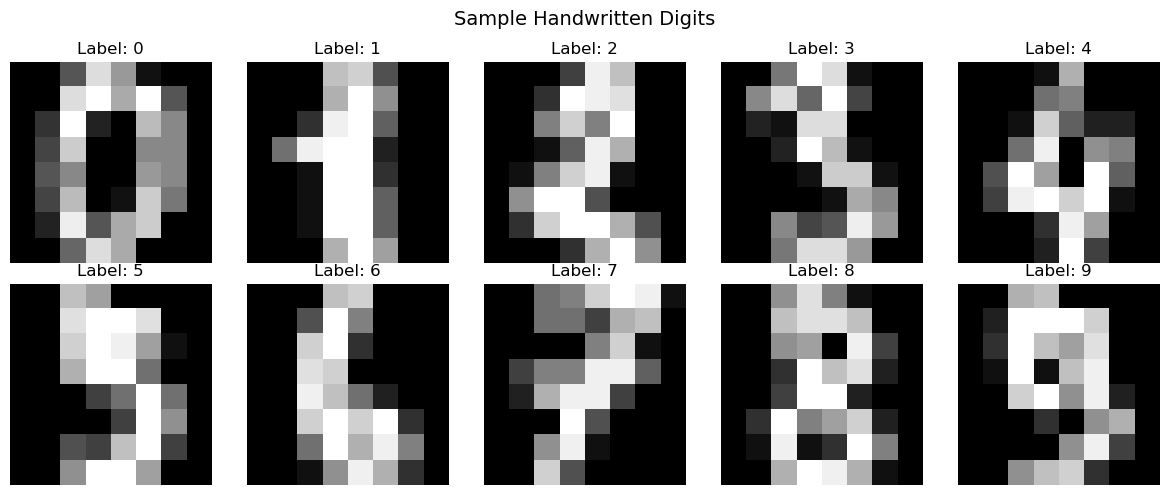

In [8]:
from sklearn.datasets import load_digits

# Load the digits dataset
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

print("Handwritten Digits Dataset")
print("="*50)
print(f"Images: {len(X_digits)}")
print(f"Image size: 8x8 pixels = 64 features")
print(f"Classes: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9")

# Show some examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('Sample Handwritten Digits', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Train a digit classifier
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42
)

digit_model = LogisticRegression(max_iter=5000)
digit_model.fit(X_train_d, y_train_d)

accuracy = digit_model.score(X_test_d, y_test_d)
print(f"Accuracy: {accuracy:.1%}")
print(f"\nThe model correctly identifies {accuracy:.1%} of handwritten digits!")

Accuracy: 97.5%

The model correctly identifies 97.5% of handwritten digits!


97.5% on 10 classes from tiny 8x8 images - not bad for a simple model. Let's see some actual predictions, including a couple the model gets wrong:

In [ ]:
# Show some predictions - pick indices that include at least one mistake
all_preds = digit_model.predict(X_digits)
wrong_indices = np.where(all_preds != y_digits)[0]
correct_indices = np.where(all_preds == y_digits)[0]

# Mix of correct and incorrect
if len(wrong_indices) >= 2:
    sample_indices = list(np.random.choice(correct_indices, 3, replace=False)) + list(wrong_indices[:2])
else:
    sample_indices = [10, 25, 42, 88, 100]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for ax, idx in zip(axes, sample_indices):
    img = digits.images[idx]
    true_label = digits.target[idx]
    pred_label = all_preds[idx]
    
    ax.imshow(img, cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Model Predictions (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.show()

## The Common Thread

Three completely different problems - medicine, finance, handwriting - but the same approach:

| Domain | Input | Output | Stakes |
|--------|-------|--------|--------|
| Medical | Cell measurements | Benign / Malignant | Life or death |
| Finance | Transaction data | Legitimate / Fraud | Money |
| OCR | Pixel values | 0-9 | Convenience |

In every case: collect labeled examples, train a model to find patterns, use those patterns to classify new data. That's the classification pipeline, and it's the same training loop from L3 - gradient descent adjusting weights to minimize a loss function.

But notice something different from regression. In L3, the output was a number (house price). Here, the output is a probability: "87% chance this is malignant" or "99.7% chance this transaction is legitimate." The model needs to express confidence, not just pick a category. That shift - from raw numbers to probabilities - is the core technical challenge we'll solve in this lesson.

Let's work through it step by step using a dataset where the patterns are intuitive.

Now that we've seen classification work across different domains, let's slow down and build a classifier from scratch. We'll use the Titanic dataset - a classic binary classification problem where the patterns are intuitive and the results are meaningful.

We'll build two models of increasing sophistication:
1. **Logistic Regression** - the simplest classifier, basically linear regression with a twist
2. **Neural Network (MLP)** - more powerful, can learn patterns logistic regression can't

Along the way, we'll introduce two new tools: **sigmoid** (turns numbers into probabilities) and **cross-entropy loss** (the loss function for classification). Everything else - gradient descent, the training loop, weight updates - stays exactly the same as L3.

## The Titanic Dataset

The Titanic disaster of 1912 is one of history's most infamous shipwrecks. Of the 2,224 passengers and crew aboard, more than 1,500 died. But survival wasn't random - it was heavily influenced by factors like gender, ticket class, and age. "Women and children first" wasn't just a phrase, it was a real policy that shaped who lived and who died.

Our goal: given information about a passenger (their age, ticket class, gender, fare paid), predict whether they survived. This is a **binary classification** problem - two possible outcomes (survived or died), and we need to find the boundary that separates them.

Why Titanic? Because the features are intuitive. When you see that the model learned to weight "female" heavily toward survival, you'll know it learned something real - not just statistical noise. That interpretability makes it a great dataset for understanding how classifiers work.

Let's look at the actual data:

In [11]:
titanic = pd.read_csv(DATA_PATH / "titanic" / "titanic.csv")
print(f"Dataset: {len(titanic)} passengers")
titanic.head(10)

Dataset: 891 passengers


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Visualizing the Classification Problem

Before we build any model, let's see what classification actually looks like visually. We'll plot two features - Age and Fare - and color each passenger by whether they survived (blue) or died (red).

This is the fundamental challenge of classification: you have two groups mixed together in feature space, and you need to find a way to separate them. Look at the plot and ask yourself: **how would you draw a line to separate the blue dots from the red dots?**

Plotting 711 passengers


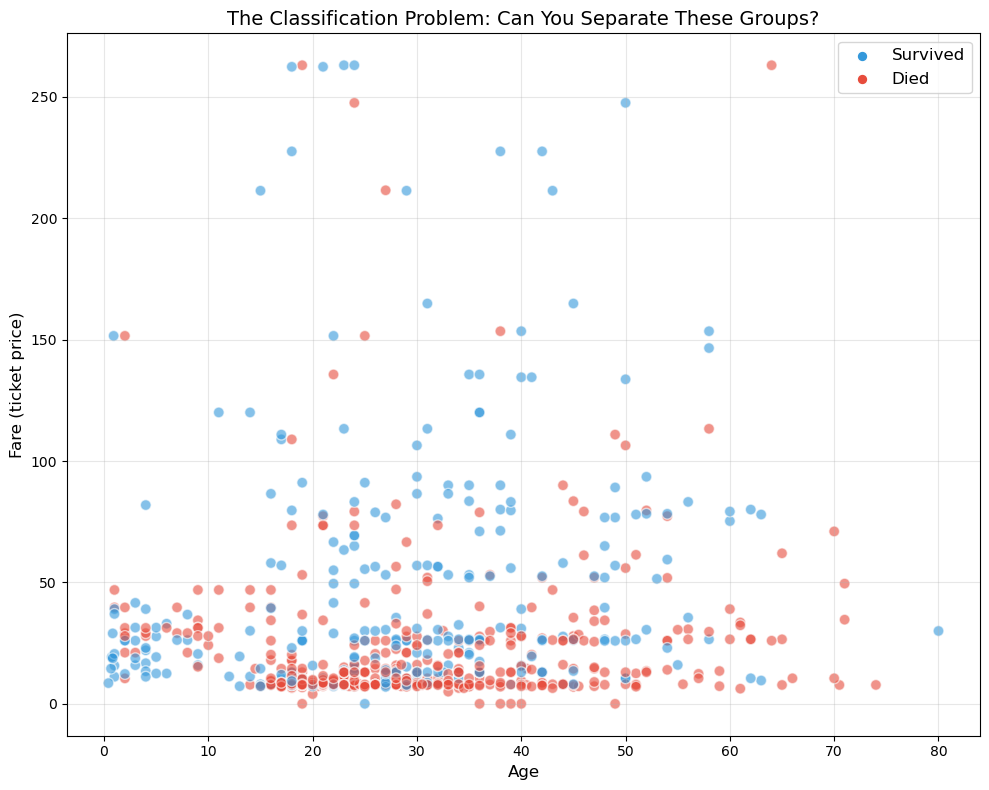

In [12]:
# Get passengers with known age and reasonable fare (for cleaner visualization)
titanic_viz = titanic.dropna(subset=['Age'])
titanic_viz = titanic_viz[titanic_viz['Fare'] < 300]  # Remove a few extreme outliers

ages = titanic_viz['Age'].values
fares = titanic_viz['Fare'].values
survived = titanic_viz['Survived'].values

print(f"Plotting {len(ages)} passengers")
plot_classification_problem(ages, fares, survived)

It's messy, right? The blue and red dots are mixed together - there's no perfect line that separates them completely. That's the reality of most classification problems. Unlike a textbook diagram where two groups are neatly separated, real data overlaps. Some 3rd-class passengers with cheap tickets survived. Some 1st-class passengers with expensive tickets died.

But we can still find a **decision boundary** - a line (or curve) where the model switches its prediction from one class to the other. Everything on one side we predict "survived", everything on the other we predict "died." The boundary won't be perfect, but it can be *useful*.

Let's try drawing one by hand:

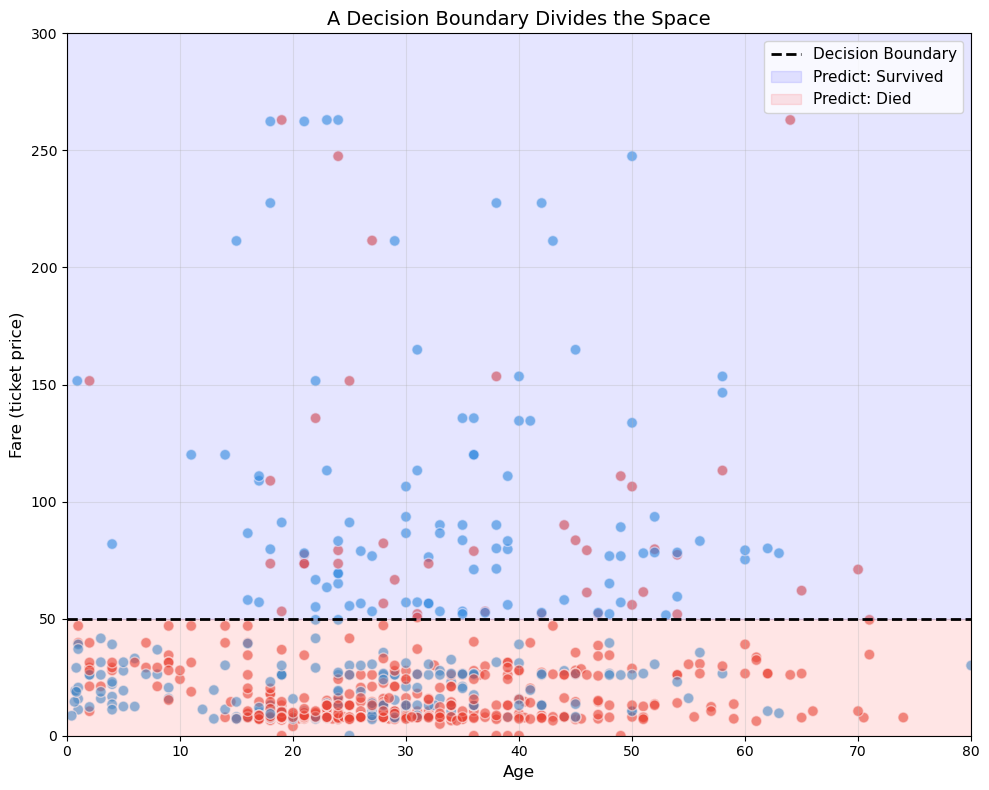

In [13]:
# Let's draw a simple boundary: Fare = 50 (horizontal line)
# Anyone above pays more → predict survived, below → predict died
plot_manual_boundary(ages, fares, survived, slope=0, intercept=50)

This boundary says: "If your fare was above $50, predict survived. Otherwise, predict died."

It's a simple rule, and it captures something real — passengers who paid more for tickets were more likely to survive (they were in better cabins, closer to lifeboats).

But how good is this boundary? Let's measure it:

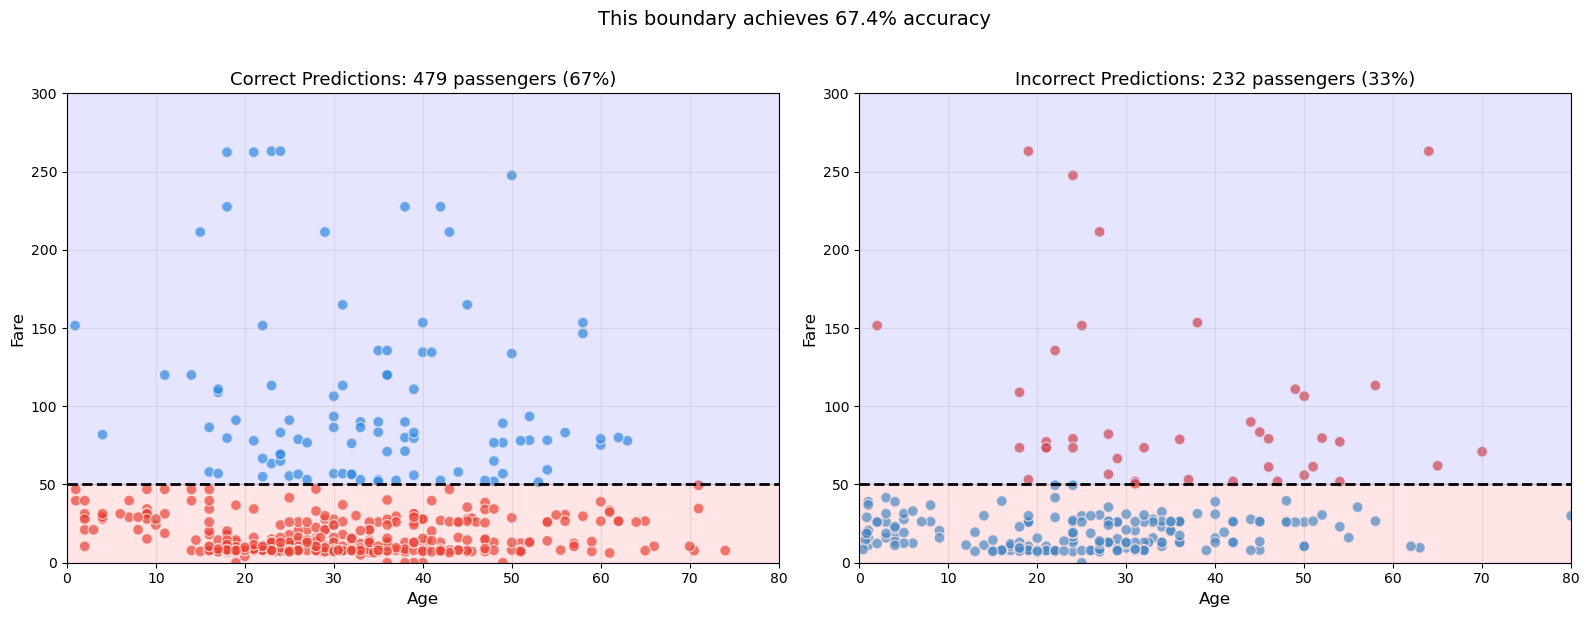

In [14]:
accuracy = plot_boundary_accuracy(ages, fares, survived, slope=0, intercept=50)

### Try It Yourself: Draw the Best Boundary

Can you beat 67%? Use the sliders to adjust the boundary line - change its angle and position. The accuracy updates in real time. Try to separate as many blue dots (survived) from red dots (died) as you can:

In [15]:
# Interactive: draw your own decision boundary
from ipywidgets import FloatSlider, IntSlider, VBox, HBox, interactive_output
from IPython.display import display, Image as IPImage

slope_slider = FloatSlider(min=-5, max=5, step=0.1, value=0,
    description='Slope:', style={'description_width': '80px'}, layout={'width': '450px'})
intercept_slider = FloatSlider(min=-50, max=200, step=5, value=50,
    description='Intercept:', style={'description_width': '80px'}, layout={'width': '450px'})

def on_boundary_change(slope, intercept):
    fig = plot_interactive_boundary_fig(ages, fares, survived, slope, intercept)
    display(IPImage(data=_render_fig(fig)))

out3 = interactive_output(on_boundary_change, {'slope': slope_slider, 'intercept': intercept_slider})
display(VBox([HBox([slope_slider, intercept_slider]), out3]))

## From Manual Rules to Learning

Our simple "fare > $50" boundary gets about 67% accuracy. Better than random guessing, but not by much - guessing "died" for everyone would get ~62% since 62% of passengers died.

We could keep trying different boundaries by hand - fare > $30, age < 10, some diagonal line combining age and fare. But that's tedious and unreliable. We'd be guessing and checking forever, and we'd probably miss patterns that aren't obvious to the human eye.

What we want is what we had in L3: an algorithm that **learns the best boundary from the data automatically**. Give it labeled examples (passengers we know survived or died), and let gradient descent find the weights that draw the best separating line.

But there's a catch. In L3, our model output a number (house price) and we used MSE to measure how wrong it was. Here, the output should be a **probability** - "72% chance this passenger survived." That's a fundamentally different kind of output, and it needs different tools.

Before we build those tools, let's look at what patterns exist in the data that a model could learn from.

## What Predicts Survival?

Let's look at survival rates broken down by different factors. These patterns tell us which features are most useful for separating the groups.

Overall survival rate: 38.4%



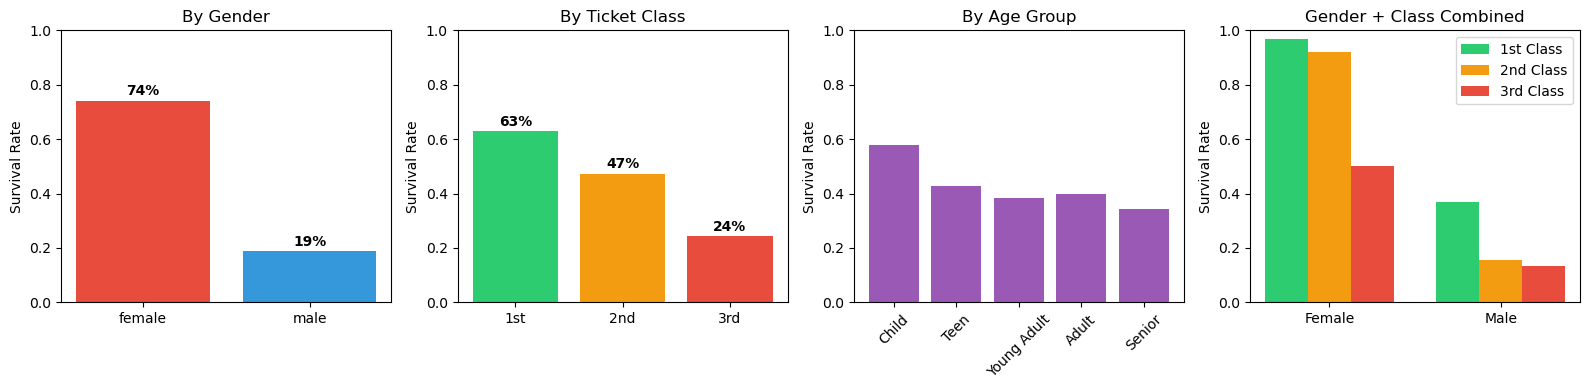

In [16]:
print(f"Overall survival rate: {titanic['Survived'].mean():.1%}\n")
plot_survival_rates(titanic)

Strong patterns emerge:

- **Gender is the strongest signal**: 74% of women survived vs only 19% of men. "Women and children first" wasn't just a policy - it was the dominant factor in who lived and died.
- **Class matters a lot**: 63% of 1st class survived vs 24% of 3rd class. Wealth bought proximity to lifeboats.
- **The combination is even more powerful**: A woman in 1st class had 97% survival; a man in 3rd class had only 14%.

These patterns are exactly what a classifier needs to learn. It should discover: "If female AND 1st class, predict survived with high confidence. If male AND 3rd class, predict died with high confidence." The question is: how do we take these patterns and turn them into a mathematical model that can make predictions on new passengers?

Let's start with something we already know - linear regression - and see why it breaks down for classification.

## From Numbers to Probabilities: The Core Challenge

In L3, our model predicted continuous numbers - house prices that could be anything on a scale. Classification is different. The data only has two outcomes: survived (1) or died (0). There's nothing in between. No one half-survived.

Let's see what this looks like. Here's Fare on the x-axis, and the outcome (0 or 1) on the y-axis:

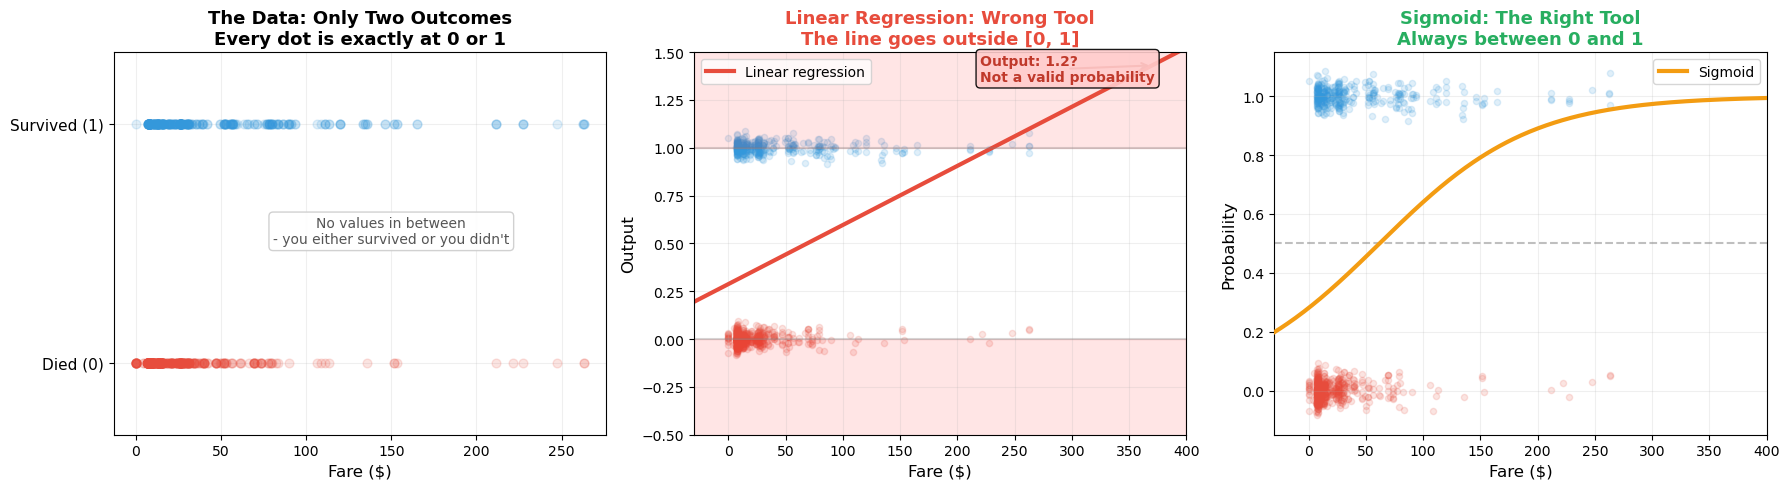

Left:   The actual data. Every passenger is either 0 (died) or 1 (survived). Nothing in between.
Middle: Linear regression draws a straight line - but it goes past 1 and below 0. Not probabilities.
Right:  Sigmoid curves through the data and always stays in [0, 1]. This is what we need.


In [17]:
# Binary data: outcomes are ONLY 0 or 1, nothing in between
fare_clean = titanic[['Fare', 'Survived']].dropna()
fare_clean = fare_clean[fare_clean['Fare'] < 300]
X_fare_raw = fare_clean['Fare'].values
y_fare_raw = fare_clean['Survived'].values

lin, log_model, w_sig, b_sig = plot_binary_linear_sigmoid(X_fare_raw, y_fare_raw, sigmoid)

print("Left:   The actual data. Every passenger is either 0 (died) or 1 (survived). Nothing in between.")
print("Middle: Linear regression draws a straight line - but it goes past 1 and below 0. Not probabilities.")
print("Right:  Sigmoid curves through the data and always stays in [0, 1]. This is what we need.")

The middle panel shows the problem clearly: a straight line through binary data overshoots past 1 and dips below 0. For a passenger with a $350 fare, the model might output 1.2. What does that mean? 120% chance of survival? That's nonsense.

The right panel shows the solution: the **sigmoid** function curves through the same data and stays bounded between 0 and 1. That's a valid probability.

Let's look at some specific numbers to make this concrete:

In [18]:
# What does the linear model actually output for specific passengers?
# (using the linear regression from the visualization above)
fare_mean = X_fare_raw.mean()
fare_std = X_fare_raw.std()
fare_norm = (X_fare_raw - fare_mean) / fare_std

# Reuse the linear model fit from above
example_fares = [5, 15, 50, 100, 200, 350]
print("The linear regression model outputs for specific passengers:")
print(f"\n{'Fare':>8}  {'Raw output':>12}  {'Problem'}")
print("-" * 60)
for fare in example_fares:
    output = lin.predict([[fare]])[0]
    if output < 0:
        problem = f"{output:.2f} - Negative. What's a negative probability?"
    elif output > 1:
        problem = f"{output:.2f} - Above 1. 120% chance of survival?"
    else:
        problem = f"{output:.2f} - In range, but not really a probability"
    print(f"${fare:>6}  {output:>12.3f}  {problem}")

print("\nThe output is just a number on a line. It has no concept of 'probability'.")
print("We need something that always stays between 0 and 1.")

The linear regression model outputs for specific passengers:

    Fare    Raw output  Problem
------------------------------------------------------------
$     5         0.303  0.30 - In range, but not really a probability
$    15         0.334  0.33 - In range, but not really a probability
$    50         0.442  0.44 - In range, but not really a probability
$   100         0.596  0.60 - In range, but not really a probability
$   200         0.905  0.91 - In range, but not really a probability
$   350         1.369  1.37 - Above 1. 120% chance of survival?

The output is just a number on a line. It has no concept of 'probability'.
We need something that always stays between 0 and 1.


The raw output is just a number on a line. For some fare values it happens to fall between 0 and 1, but that's coincidence - it's not bounded. The model has no concept of probability.

We need a function that takes these raw numbers and **squashes** them into the range [0, 1]. It should be smooth (so gradient descent works), output 0.5 when uncertain, and approach 0 and 1 at the extremes. That function is the **sigmoid**.

## The Sigmoid Function

The **sigmoid function** takes any number and maps it to a value between 0 and 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Don't worry about the formula. What matters is the shape and what it does:

- Large negative z (like -5) -> output near 0: "almost certainly class 0 (died)"
- Large positive z (like +5) -> output near 1: "almost certainly class 1 (survived)"
- z = 0 -> output exactly 0.5: maximally uncertain, 50/50

The S-shape is steep in the middle (where small changes flip the prediction) and flat at the extremes (where the model is already confident). This is exactly what we want for probabilities.

Let's see it on a clean dataset first, then come back to Titanic. Here's a synthetic example: students studying for an exam. Hours studied vs pass/fail - the pattern is obvious and the sigmoid fits beautifully:

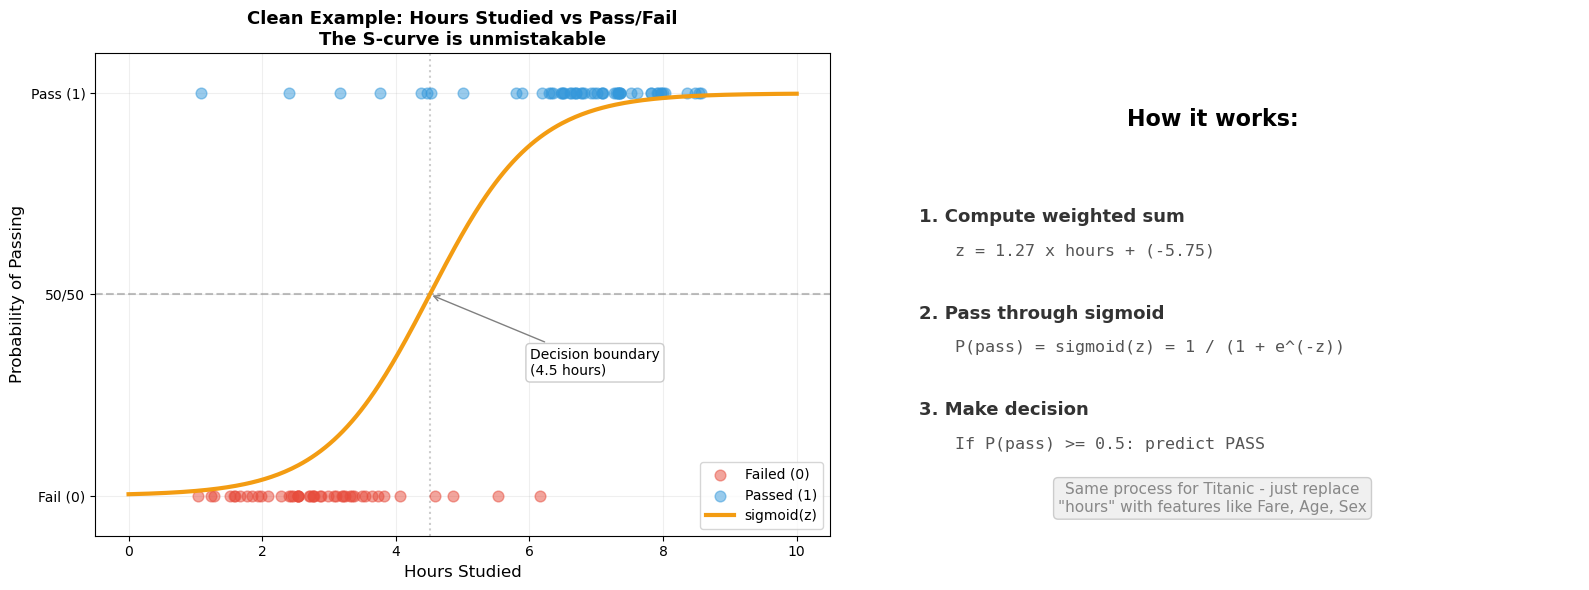

This is the classic sigmoid in action.
Below ~4 hours: almost certainly fail. Above ~6 hours: almost certainly pass.
The boundary is where the curve crosses 0.5.


In [19]:
# Sigmoid on a clean dataset where the pattern is obvious
plot_sigmoid_clean_example(sigmoid)

print("This is the classic sigmoid in action.")
print("Below ~4 hours: almost certainly fail. Above ~6 hours: almost certainly pass.")
print("The boundary is where the curve crosses 0.5.")

That's a textbook sigmoid - the S-curve is steep and clear because hours studied is a strong predictor of passing. In real datasets like Titanic, the sigmoid is often flatter because single features are weaker predictors. Fare alone doesn't strongly determine survival (gender matters much more). But the principle is identical.

Now let's apply sigmoid to the Titanic fare values we saw earlier and see the raw z values transformed into probabilities:

In [20]:
# Same passengers, but now we run the raw output through sigmoid
# Using the logistic regression model (w_sig, b_sig) from the 3-panel viz
print(f"{'Fare':>8}  {'Raw z':>8}  {'sigmoid(z)':>12}  {'Interpretation'}")
print("-" * 65)
for fare in example_fares:
    z = w_sig * fare + b_sig
    p = sigmoid(z)
    if p < 0.3:
        interp = f"Low confidence survived ({p:.0%})"
    elif p > 0.7:
        interp = f"High confidence survived ({p:.0%})"
    else:
        interp = f"Uncertain ({p:.0%})"
    print(f"${fare:>6}  {z:>8.3f}  {p:>12.3f}  {interp}")

print(f"\nEvery output is now between 0 and 1. These are actual probabilities we can use.")

    Fare     Raw z    sigmoid(z)  Interpretation
-----------------------------------------------------------------
$     5    -0.865         0.296  Low confidence survived (30%)
$    15    -0.713         0.329  Uncertain (33%)
$    50    -0.182         0.455  Uncertain (45%)
$   100     0.578         0.641  Uncertain (64%)
$   200     2.097         0.891  High confidence survived (89%)
$   350     4.375         0.988  High confidence survived (99%)

Every output is now between 0 and 1. These are actual probabilities we can use.


### Explore: What Threshold Should We Use?

Sigmoid gives us a probability. But we still need to make a decision: survived or died? The standard threshold is 0.5 - anything above we call "survived." But what if we used 0.3? Or 0.7? Try it below and watch how the predictions change:

In [21]:
# Interactive: change the threshold and see how predictions change
threshold_slider = FloatSlider(min=0.05, max=0.95, step=0.05, value=0.5,
    description='Threshold:', style={'description_width': '100px'}, layout={'width': '500px'})

died = y_fare_raw == 0
surv = y_fare_raw == 1
probs_all = sigmoid(w_sig * X_fare_raw + b_sig)

def on_threshold_change(threshold):
    fig = plot_threshold_fig(X_fare_raw, y_fare_raw, probs_all, w_sig, b_sig, threshold, sigmoid)
    display(IPImage(data=_render_fig(fig)))

out = interactive_output(on_threshold_change, {'threshold': threshold_slider})
display(VBox([threshold_slider, out]))

That's the whole picture for a single feature. The linear model computes `z = w * fare + b`, sigmoid squashes z into a probability, and we pick a threshold to make a decision. Together, this is called **logistic regression**.

Now let's scale up: use all four features (Pclass, Sex, Age, Fare) and train a proper logistic regression model with gradient descent.

## Logistic Regression = Linear Model + Sigmoid

Now we have the missing piece. **Logistic regression** is just our linear model from L3 with sigmoid wrapped around it:

1. Compute the weighted sum: `z = w1 * pclass + w2 * sex + w3 * age + w4 * fare + bias`
2. Squash to a probability: `probability = sigmoid(z)`
3. Classify: if probability >= 0.5, predict "survived"

Step 1 is identical to L3 - a dot product of features and weights. Step 2 is new - we pass that number through sigmoid so it becomes a valid probability. Step 3 is just applying a threshold.

The weights still start random. Gradient descent still optimizes them. The training loop is the same: forward pass, compute loss, backward pass, update weights. The only structural change is that sigmoid sits between the linear computation and the output.

But we do need a different loss function. MSE measured "how far off is my number?" Cross-entropy measures "how wrong is my probability?" And it turns out that distinction matters a lot for how well the model learns.

## Preparing the Data

Let's prepare the Titanic data for training. We'll use four key features.

In [22]:
# Select features and handle missing values
features = ['Pclass', 'Sex', 'Age', 'Fare']

# Create a clean dataset
data = titanic[features + ['Survived']].copy()
data['Sex'] = (data['Sex'] == 'male').astype(int)  # Convert to 0/1
data = data.dropna()  # Drop rows with missing Age

print(f"Clean dataset: {len(data)} passengers")
print(f"Features: {features}")
data.head()

Clean dataset: 714 passengers
Features: ['Pclass', 'Sex', 'Age', 'Fare']


,Pclass,Sex,Age,Fare,Survived
0,3,1,22.0,7.2500,0
1,1,0,38.0,71.2833,1
2,3,0,26.0,7.9250,1
3,1,0,35.0,53.1000,1
4,3,1,35.0,8.0500,0


Now we split into training and validation sets (same principle as L3 - never evaluate on data the model trained on) and normalize the features so gradient descent converges smoothly:

In [23]:
# Split into features (X) and target (y)
X = data[features].values
y = data['Survived'].values

# Split into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features (important for gradient descent)
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")

Training set: 571 samples
Validation set: 143 samples


## Training with Gradient Descent (and a New Loss Function)

The training loop is the same as L3 - forward pass, compute loss, compute gradients, update weights. But we need a different loss function.

### Why Not MSE for Classification?

In regression, MSE works great: it measures the squared distance between prediction and target. But for classification, there's a problem. Imagine the model predicts 0.99 (99% confident survived) and the passenger actually died. That's a catastrophically wrong prediction - the model was highly confident and completely wrong. MSE would penalize this as (0.99 - 0)^2 = 0.98. Not great, but not that different from a prediction of 0.8 which gives (0.8 - 0)^2 = 0.64.

We want a loss function that **heavily punishes confident wrong answers**. Being 99% wrong should be dramatically worse than being 80% wrong, not just slightly worse.

### Cross-Entropy Loss

**Cross-entropy loss** (also called **binary cross-entropy** or **BCE**) does exactly this. The formula involves logarithms, which blow up as predictions approach 0:

- Model says 0.99 survived, actually died: loss = -log(1 - 0.99) = -log(0.01) = 4.6 (huge!)
- Model says 0.8 survived, actually died: loss = -log(1 - 0.8) = -log(0.2) = 1.6 (moderate)
- Model says 0.51 survived, actually died: loss = -log(1 - 0.51) = -log(0.49) = 0.7 (small)

See the pattern? As the model gets more confidently wrong, the loss explodes exponentially. This is exactly the incentive structure we want - it forces the model to be honest about its uncertainty. If you're not sure, say 0.5, don't bluff with 0.95.

You don't need to memorize the formula. Just remember: cross-entropy is for classification, MSE is for regression. The gradient computation is different too, but again - PyTorch handles that automatically.

Let's implement it and train:

In [24]:
# Interactive: see how cross-entropy vs MSE penalize wrong predictions
pred_slider = FloatSlider(min=0.01, max=0.99, step=0.01, value=0.9,
    description='Prediction:', style={'description_width': '100px'}, layout={'width': '500px'})

def on_pred_change(prediction):
    fig = plot_loss_comparison_fig(prediction)
    display(IPImage(data=_render_fig(fig)))

print("The passenger actually DIED. Move the slider to see what happens")
print("when the model predicts different probabilities of survival:")
out2 = interactive_output(on_pred_change, {'prediction': pred_slider})
display(VBox([pred_slider, out2]))

The passenger actually DIED. Move the slider to see what happens
when the model predicts different probabilities of survival:


Now let's implement logistic regression and train it. The functions are almost identical to L3 - we just swap in sigmoid and cross-entropy:

In [25]:
def logistic_regression_predict(X, w, b):
    """Compute predictions: sigmoid(X @ w + b)"""
    z = X @ w + b
    return sigmoid(z)

def compute_loss(y_true, y_pred):
    """Binary cross-entropy loss"""
    epsilon = 1e-15  # Avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_gradients(X, y_true, y_pred):
    """Compute gradients for w and b"""
    m = len(y_true)
    error = y_pred - y_true
    dw = (1/m) * X.T @ error
    db = (1/m) * np.sum(error)
    return dw, db

Now let's run 200 epochs of gradient descent. Watch the loss drop as the model finds better weights:

In [26]:
# Initialize with RANDOM weights (same as every ML model)
np.random.seed(42)
n_features = X_train_norm.shape[1]
w = np.random.randn(n_features) * 0.1
b = np.random.randn() * 0.1

print("Starting weights (random):")
start_df = pd.DataFrame({
    'Feature': features + ['Bias'],
    'Weight': list(w.round(4)) + [round(b, 4)],
})
display(start_df)

# Show what these random weights predict for a few passengers
sample_preds = logistic_regression_predict(X_train_norm[:5], w, b)
print("\nPredictions with random weights (first 5 passengers):")
pred_df = pd.DataFrame({
    'Pclass': X_train[:5, 0].astype(int),
    'Sex': ['Male' if s == 1 else 'Female' for s in X_train[:5, 1]],
    'Age': X_train[:5, 2].astype(int),
    'Predicted': sample_preds.round(3),
    'Actual': y_train[:5],
    'Correct?': ['Yes' if (p >= 0.5) == a else 'No' for p, a in zip(sample_preds, y_train[:5])],
})
display(pred_df)
print("With random weights, the model is guessing randomly. Let's fix that.\n")

# Training hyperparameters
learning_rate = 0.1
n_epochs = 200

# Track everything
train_losses = []
val_losses = []
weight_history = [(w.copy(), b)]

# Training loop
for epoch in range(n_epochs):
    # Forward pass
    y_pred_train = logistic_regression_predict(X_train_norm, w, b)
    y_pred_val = logistic_regression_predict(X_val_norm, w, b)
    
    # Compute loss
    train_loss = compute_loss(y_train, y_pred_train)
    val_loss = compute_loss(y_val, y_pred_val)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # Compute gradients
    dw, db = compute_gradients(X_train_norm, y_train, y_pred_train)
    
    # Update weights
    w = w - learning_rate * dw
    b = b - learning_rate * db
    weight_history.append((w.copy(), b))
    
    if epoch in [0, 4, 19, 49, 99, 199]:
        acc = np.mean((y_pred_train >= 0.5).astype(int) == y_train)
        print(f"  Epoch {epoch+1:>3d}: Loss = {train_loss:.4f}  Accuracy = {acc:.1%}  "
              f"w = [{', '.join(f'{x:+.3f}' for x in w)}]  b = {b:+.3f}")

print(f"\nFinal weights after {n_epochs} epochs:")
final_df = pd.DataFrame({
    'Feature': features + ['Bias'],
    'Start (random)': list(weight_history[0][0].round(4)) + [round(weight_history[0][1], 4)],
    'Final (trained)': list(w.round(4)) + [round(b, 4)],
})
display(final_df)

Starting weights (random):


,Feature,Weight
0,Pclass,0.0497
1,Sex,-0.0138
2,Age,0.0648
3,Fare,0.1523
4,Bias,-0.0234



Predictions with random weights (first 5 passengers):


,Pclass,Sex,Age,Predicted,Actual,Correct?
0,3,Female,31,0.500,1,Yes
1,3,Male,26,0.483,0,Yes
2,3,Male,30,0.488,0,Yes
3,3,Male,33,0.485,0,Yes
4,2,Male,25,0.466,0,Yes


With random weights, the model is guessing randomly. Let's fix that.

  Epoch   1: Loss = 0.6816  Accuracy = 60.8%  w = [+0.035, -0.041, +0.057, +0.163]  b = -0.032
  Epoch   5: Loss = 0.6390  Accuracy = 73.9%  w = [-0.020, -0.141, +0.027, +0.199]  b = -0.063
  Epoch  20: Loss = 0.5462  Accuracy = 78.1%  w = [-0.170, -0.431, -0.069, +0.281]  b = -0.157
  Epoch  50: Loss = 0.4824  Accuracy = 78.5%  w = [-0.351, -0.767, -0.201, +0.332]  b = -0.268
  Epoch 100: Loss = 0.4557  Accuracy = 78.6%  w = [-0.534, -1.022, -0.332, +0.317]  b = -0.360
  Epoch 200: Loss = 0.4441  Accuracy = 79.5%  w = [-0.753, -1.187, -0.465, +0.219]  b = -0.434

Final weights after 200 epochs:


,Feature,Start (random),Final (trained)
0,Pclass,0.0497,-0.7528
1,Sex,-0.0138,-1.1869
2,Age,0.0648,-0.4654
3,Fare,0.1523,0.2193
4,Bias,-0.0234,-0.4340


Now let's look at the same 5 passengers from before - with trained weights instead of random ones:

In [ ]:
# Same passengers, now with trained weights - use 10 for a fairer comparison
n_show = 10
trained_preds = logistic_regression_predict(X_train_norm[:n_show], w, b)
random_preds = logistic_regression_predict(X_train_norm[:n_show], *weight_history[0])

compare_df = pd.DataFrame({
    'Pclass': X_train[:n_show, 0].astype(int),
    'Sex': ['Male' if s == 1 else 'Female' for s in X_train[:n_show, 1]],
    'Age': X_train[:n_show, 2].astype(int),
    'Before (random)': random_preds.round(3),
    'After (trained)': trained_preds.round(3),
    'Actual': y_train[:n_show],
})
print("Same passengers, before and after training:")
display(compare_df)

random_acc = np.mean((random_preds >= 0.5).astype(int) == y_train[:n_show])
trained_acc = np.mean((trained_preds >= 0.5).astype(int) == y_train[:n_show])
full_acc = np.mean((logistic_regression_predict(X_train_norm, w, b) >= 0.5).astype(int) == y_train)

print(f"\nRandom weights accuracy (these {n_show}): {random_acc:.0%}")
print(f"Trained weights accuracy (these {n_show}): {trained_acc:.0%}")
print(f"Trained weights accuracy (all {len(y_train)} training): {full_acc:.1%}")
print(f"\nNotice how the trained probabilities make sense: females get high survival probability,")
print(f"males in 3rd class get low. The random weights had no such pattern.")

In [ ]:
# Visualize how each weight evolved during training
plot_weight_evolution(weight_history, features, train_losses, val_losses)

print("Left:  Each weight starts random and converges to a stable value.")
print("       Sex (blue) has the largest magnitude - it's the strongest predictor.")
print("Right: Cross-entropy loss drops as the weights improve. Both train and val drop together - good sign.")

## Evaluating the Model

The loss dropped during training - that's a good sign. But loss is an abstract number. Let's translate it into something more concrete: how often does the model get the right answer?

We convert each probability to a class prediction using a threshold of 0.5: if the model says "60% chance of survival," we predict survived. If it says "40%," we predict died. Then we count how many predictions match the actual outcomes.

In [29]:
# Make predictions
y_pred_train = logistic_regression_predict(X_train_norm, w, b)
y_pred_val = logistic_regression_predict(X_val_norm, w, b)

# Convert probabilities to class predictions (threshold = 0.5)
y_pred_train_class = (y_pred_train >= 0.5).astype(int)
y_pred_val_class = (y_pred_val >= 0.5).astype(int)

# Calculate accuracy
train_accuracy = np.mean(y_pred_train_class == y_train)
val_accuracy = np.mean(y_pred_val_class == y_val)

print(f"Training Accuracy: {train_accuracy:.1%}")
print(f"Validation Accuracy: {val_accuracy:.1%}")
print(f"\nMuch better than our manual 'fare > $50' boundary ({accuracy:.1%})!")

Training Accuracy: 79.5%
Validation Accuracy: 74.8%

Much better than our manual 'fare > $50' boundary (67.4%)!


## What Did the Model Learn?

Remember, the model started with random weights and gradient descent adjusted them to minimize cross-entropy loss. The final weights tell us what the model discovered about survival patterns. Each weight represents how much that feature influences the model's prediction - a large positive weight pushes toward "survived," a large negative weight pushes toward "died."

Let's see if the model learned the same patterns we noticed earlier in the data exploration:

In [30]:
print("Learned weights (what moves you toward 'survived' side of boundary):")
print("-" * 60)
for feature, weight in zip(features, w):
    if weight > 0:
        effect = "↑ increases survival probability"
    else:
        effect = "↓ decreases survival probability"
    print(f"  {feature:10s}: {weight:+.3f}  {effect}")
print(f"  {'Bias':10s}: {b:+.3f}")

Learned weights (what moves you toward 'survived' side of boundary):
------------------------------------------------------------
  Pclass    : -0.753  ↓ decreases survival probability
  Sex       : -1.187  ↓ decreases survival probability
  Age       : -0.465  ↓ decreases survival probability
  Fare      : +0.219  ↑ increases survival probability
  Bias      : -0.434


The model learned exactly what we expected from the data exploration:

- **Sex** (male=1) has the largest negative weight - being male strongly pushes the prediction toward "died." This is the model discovering "women and children first" from the data alone.
- **Pclass** has a negative weight - higher class number (3rd class = 3) pushes toward "died." Wealthier passengers had better access to lifeboats.
- **Age** has a small negative weight - older passengers were slightly less likely to survive.
- **Fare** has a positive weight - higher fare pushes toward "survived," likely because it correlates with cabin location.

These weights weren't programmed by us. Gradient descent found them by minimizing cross-entropy loss over hundreds of epochs. The model looked at 571 labeled passengers and discovered the historical survival patterns on its own.

This is one of the most satisfying moments in ML: the model's learned weights tell a story that matches real history. But there's a limitation we should see.

## Visualizing the Learned Boundary

Let's train a simpler model using just Age and Fare so we can visualize the decision boundary in 2D. The boundary is the line where the model switches from predicting "died" to predicting "survived."

In [31]:
# Train a 2D model for visualization - save weights at every epoch
X_2d = data[['Age', 'Fare']].values
y_2d = data['Survived'].values

X_train_2d, X_val_2d, y_train_2d, y_val_2d = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42)

# Normalize
X_mean_2d = X_train_2d.mean(axis=0)
X_std_2d = X_train_2d.std(axis=0)
X_train_2d_norm = (X_train_2d - X_mean_2d) / X_std_2d
X_val_2d_norm = (X_val_2d - X_mean_2d) / X_std_2d

# Train and save weights at each epoch for the slider
w_2d = np.zeros(2)
b_2d = 0.0
w_history_2d = [(w_2d.copy(), b_2d)]

for epoch in range(500):
    y_pred = logistic_regression_predict(X_train_2d_norm, w_2d, b_2d)
    dw, db = compute_gradients(X_train_2d_norm, y_train_2d, y_pred)
    w_2d = w_2d - 0.1 * dw
    b_2d = b_2d - 0.1 * db
    w_history_2d.append((w_2d.copy(), b_2d))

val_acc_2d = np.mean((logistic_regression_predict(X_val_2d_norm, w_2d, b_2d) >= 0.5) == y_val_2d)
print(f"2D model validation accuracy: {val_acc_2d:.1%}")
print(f"Saved weights at {len(w_history_2d)} epochs for interactive exploration.")

2D model validation accuracy: 62.9%
Saved weights at 501 epochs for interactive exploration.


Let's see that boundary on the scatter plot. The dashed line is where the model switches from predicting "died" to "survived":

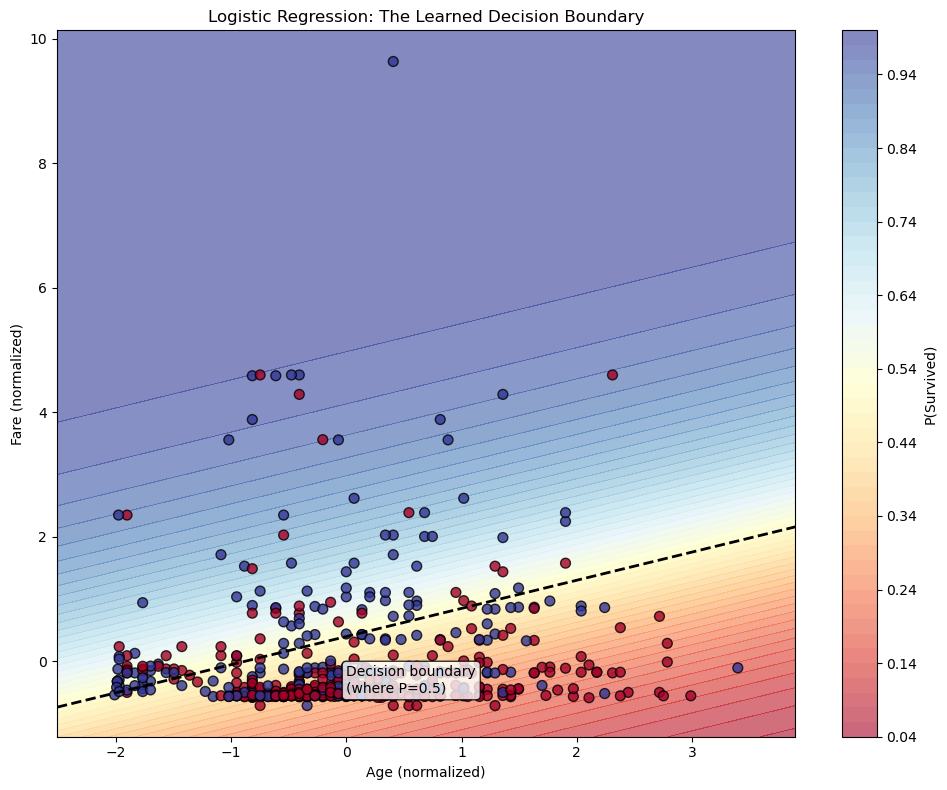

In [32]:
plot_decision_boundary_logistic(
    X_train_2d_norm, y_train_2d, w_2d, b_2d,
    f'Logistic Regression: The Learned Decision Boundary'
)

### Watch the Boundary Learn

The decision boundary above is the final result after 500 epochs of training. But it didn't start there - the weights started at zero, meaning no boundary at all. Use the slider to scrub through training and watch the boundary emerge:

In [33]:
# Interactive: watch the decision boundary evolve during training
epoch_slider = IntSlider(min=0, max=500, step=1, value=0,
    description='Epoch:', style={'description_width': '80px'}, layout={'width': '600px'})

def on_epoch_change(epoch):
    fig = plot_epoch_boundary_fig(X_train_2d_norm, y_train_2d, w_history_2d, epoch, logistic_regression_predict)
    display(IPImage(data=_render_fig(fig)))

out4 = interactive_output(on_epoch_change, {'epoch': epoch_slider})
display(VBox([epoch_slider, out4]))

## A Quick Note: Overfitting Happens in Classification Too

Remember overfitting from L3? Same thing here. If we give a classification model too many features or too much complexity, it starts memorizing the training data instead of learning real patterns.

We can demonstrate this by manufacturing **polynomial features** - taking our 2 original features (Age, Fare) and creating combinations like Age^2, Age x Fare, Fare^2. This gives the model more "knobs to turn," which lets the decision boundary curve - but push it too far and the boundary starts wrapping around individual points.

We won't go deep here since L3 covered overfitting thoroughly. Just know: the same train/val gap diagnostic applies. Watch for it when we build the neural network next - 97 parameters is a lot more than 5.

In [ ]:
# What are polynomial features? Let's see with a concrete example.
from sklearn.preprocessing import PolynomialFeatures

example_age = 25.0
example_fare = 50.0

print("Original features:")
print(f"  [Age, Fare] = [{example_age}, {example_fare}]")
print(f"  -> 2 numbers. Logistic regression draws a straight boundary.\n")

print("Degree 2 polynomial features:")
print(f"  [Age, Fare, Age^2, Age*Fare, Fare^2]")
print(f"  [{example_age}, {example_fare}, {example_age**2}, {example_age*example_fare}, {example_fare**2}]")
print(f"  -> 5 numbers. The model can now learn curved relationships.\n")

print("Degree 3 polynomial features:")
poly3 = PolynomialFeatures(3, include_bias=False)
example_expanded = poly3.fit_transform([[example_age, example_fare]])[0]
print(f"  {poly3.get_feature_names_out()}")
print(f"  -> {len(example_expanded)} numbers from just 2 original features!\n")

plot_polynomial_boundary_comparison()

print("Same logistic regression model. Same gradient descent. Just richer inputs.")

What polynomial features do: turn 2 features into many more
  Degree 1: [Age, Fare]                          -> 2 features
  Degree 3: [Age, Fare, Age^2, Age*Fare, ...]    -> 9 features
  Degree 8: [Age, Fare, ..., Age^4*Fare^4, ...]  -> 44 features

More features = more weights = more capacity to draw complex boundaries
But also more capacity to memorize noise instead of learning patterns.

  Degree 1 (straight line)        Train: 67.3%  Val: 62.9%  Gap: +4.3%  (2 weights)
  Degree 3 (gentle curves)        Train: 70.1%  Val: 62.2%  Gap: +7.8%  (9 weights)


  Degree 8 (wild boundary)        Train: 70.9%  Val: 64.3%  Gap: +6.6%  (44 weights)


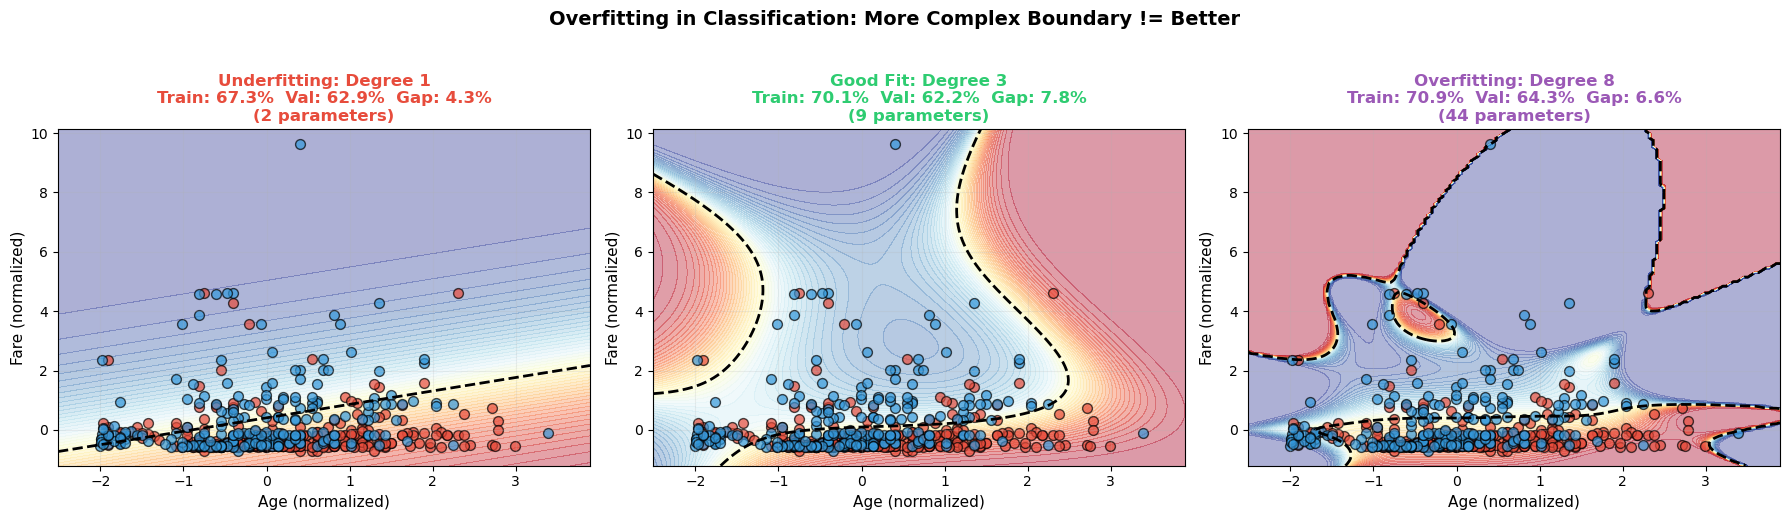

In [34]:
# Overfitting in classification: what happens when we add polynomial features?
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Three models with increasing complexity - SAME algorithm, different input complexity
models = {
    'Degree 1 (straight line)': make_pipeline(
        PolynomialFeatures(degree=1, include_bias=False),  # Just Age, Fare
        LogisticRegression(max_iter=5000)
    ),
    'Degree 3 (gentle curves)': make_pipeline(
        PolynomialFeatures(degree=3, include_bias=False),  # Age, Fare, Age^2, Fare^2, Age*Fare, ...
        LogisticRegression(max_iter=5000)
    ),
    'Degree 8 (wild boundary)': make_pipeline(
        PolynomialFeatures(degree=8, include_bias=False),  # 44 features from just 2 inputs!
        LogisticRegression(max_iter=5000, C=100.0)  # C=100 means weak regularization -> overfits easier
    ),
}

print("What polynomial features do: turn 2 features into many more")
print(f"  Degree 1: [Age, Fare]                          -> 2 features")
print(f"  Degree 3: [Age, Fare, Age^2, Age*Fare, ...]    -> {PolynomialFeatures(3, include_bias=False).fit_transform(X_train_2d_norm[:1]).shape[1]} features")
print(f"  Degree 8: [Age, Fare, ..., Age^4*Fare^4, ...]  -> {PolynomialFeatures(8, include_bias=False).fit_transform(X_train_2d_norm[:1]).shape[1]} features")
print(f"\nMore features = more weights = more capacity to draw complex boundaries")
print(f"But also more capacity to memorize noise instead of learning patterns.\n")

for name, model in models.items():
    model.fit(X_train_2d_norm, y_train_2d)
    train_acc = model.score(X_train_2d_norm, y_train_2d)
    val_acc = model.score(X_val_2d_norm, y_val_2d)
    n_params = len(model.named_steps['logisticregression'].coef_[0])
    gap = train_acc - val_acc
    print(f"  {name:30s}  Train: {train_acc:.1%}  Val: {val_acc:.1%}  Gap: {gap:+.1%}  ({n_params} weights)")

# Visualize the decision boundaries
plot_classification_overfit(X_train_2d_norm, y_train_2d, X_val_2d_norm, y_val_2d, degrees=[1, 3, 8])

The degree 8 boundary is doing exactly what overfit models do - chasing noise in the training data. The train/val gap is the giveaway.

Now, back to the main story. We've seen that logistic regression is limited to straight boundaries (unless we manually engineer polynomial features, which doesn't scale). What if the model could learn its own features automatically?

## The Limitation: Manual Feature Engineering Doesn't Scale

We just saw that polynomial features can give logistic regression curved boundaries. Degree 3 drew gentle curves, degree 8 drew wild squiggles. So the raw model is limited to straight lines, but we *can* get curves by manufacturing new features.

The problem is: we had to decide which polynomial features to create. For 2 features (Age, Fare), degree 3 gave us 9 features. That's manageable. But what if we had 50 features? Degree 3 polynomials of 50 features would create thousands of combinations. And how do you know which degree is right? Which cross-terms actually matter? You're guessing.

What if instead of us manually engineering features, the model could **figure out what transformations are useful on its own**? Instead of us saying "try Age^2 and Age x Fare," the model discovers what combinations of inputs help it classify better - automatically, through gradient descent.

That's exactly what neural networks do. The hidden layer IS the automatic feature engineering. Each neuron creates its own learned combination of the inputs. And gradient descent optimizes those combinations the same way it optimizes weights - by following the gradient downhill.

## Enter PyTorch: The Deep Learning Library

To build neural networks, we'll use **PyTorch** — the industry-standard library for deep learning. Before we dive into the code, let's understand what makes it different from NumPy.

**Why not just use NumPy?**

Remember in logistic regression, we computed gradients manually? For a simple model with 5 weights, that was manageable. But neural networks have hundreds or thousands of weights, and the gradients involve chain rules through multiple layers.

PyTorch solves this with **automatic differentiation**: it tracks all operations on your data and automatically computes gradients when you ask. You write the forward pass, PyTorch figures out the backward pass.

**The key concepts:**

| Concept | What it is |
|---------|------------|
| `Tensor` | Like a NumPy array, but can track gradients and run on GPU |
| `nn.Module` | Base class for all neural network components |
| `nn.Linear` | A layer that does `output = input @ weights + bias` |
| `nn.Sequential` | Stack multiple layers in order |
| `loss.backward()` | Compute all gradients automatically |
| `optimizer.step()` | Update all weights using those gradients |

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version: {torch.__version__}")

# Tensors are like NumPy arrays
numpy_array = np.array([1.0, 2.0, 3.0])
tensor = torch.tensor([1.0, 2.0, 3.0])

print(f"\nNumPy array: {numpy_array}")
print(f"PyTorch tensor: {tensor}")
print(f"Same operations work: tensor * 2 = {tensor * 2}")

PyTorch version: 2.9.1+cu128

NumPy array: [1. 2. 3.]
PyTorch tensor: tensor([1., 2., 3.])
Same operations work: tensor * 2 = tensor([2., 4., 6.])


Tensors look and feel like NumPy arrays, and for basic operations they work the same way. The difference is under the hood: tensors can track every operation performed on them, which is how PyTorch computes gradients automatically. You'll also see `.to(device)` - that moves data to the GPU if one is available, which makes training faster.

Before we build our PyTorch MLP, let's see how easy it is to train a neural network with sklearn - then we'll appreciate what PyTorch gives us:

In [36]:
from sklearn.neural_network import MLPClassifier

# sklearn makes it look easy...
sklearn_mlp = MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=42)
sklearn_mlp.fit(X_train_norm, y_train)

sklearn_acc = sklearn_mlp.score(X_val_norm, y_val)
print(f"sklearn MLP accuracy: {sklearn_acc:.1%}")
print(f"\nThat was easy! But sklearn hides everything.")
print(f"We can't see the weights updating, can't customize the training loop,")
print(f"can't add GPU acceleration, can't build complex architectures.")
print(f"\nFor real deep learning, we need PyTorch.")

sklearn MLP accuracy: 74.1%

That was easy! But sklearn hides everything.
We can't see the weights updating, can't customize the training loop,
can't add GPU acceleration, can't build complex architectures.

For real deep learning, we need PyTorch.


Scikit-learn's `MLPClassifier` works, but it's a black box. With PyTorch, we'll see exactly what's happening — and that understanding is what lets you build more sophisticated models later.

Let's build the same network in PyTorch:

## The Multi-Layer Perceptron (MLP)

A **Multi-Layer Perceptron** is logistic regression with extra layers in the middle. Instead of going directly from input features to output prediction, the data passes through one or more **hidden layers** first. Each hidden layer transforms the data, creating new intermediate features that the next layer can use.

```
Input (4 features: Pclass, Sex, Age, Fare)
       |
Hidden Layer (16 neurons - learns feature combinations)
       |
Output (1 neuron - probability of survival)
```

The hidden layer is where the magic happens. Each neuron in the hidden layer computes its own weighted sum of the inputs - just like logistic regression - but then passes the result through an activation function (ReLU, not sigmoid). With 16 neurons, the network creates 16 different "views" of the data. Some might learn "young female passenger" as an important combination. Others might learn "3rd class with low fare." The network figures out what combinations are useful for predicting survival.

The output layer then takes those 16 learned features and combines them into a single probability using sigmoid - exactly like logistic regression, but operating on features the network created instead of raw input features.

Let's build one in PyTorch:

In [37]:
class MLP(nn.Module):
    """A simple neural network with one hidden layer."""
    
    def __init__(self, n_features, n_hidden=16):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_features, n_hidden),  # Input -> Hidden
            nn.ReLU(),                         # Activation function - this is super important, but we'll talk more about it later.
            nn.Linear(n_hidden, 1),            # Hidden -> Output
            nn.Sigmoid()                       # Squash to probability - look, we're using sigmoid again! The reason is because we're doing binary classification. There are other activation functions that can do stuff with our output. 
        )
    
    def forward(self, x):
        return self.layers(x)

# Create the model
mlp = MLP(n_features=4, n_hidden=16).to(device)
print(mlp)

MLP(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


Notice the parameter count difference. Logistic regression has just 5 parameters (one weight per feature + bias). The MLP has 97 - all the connections between layers. More parameters means more capacity to learn complex patterns, but also more potential to overfit on small datasets.

Let's convert our data to PyTorch tensors and train:

In [38]:
# How many parameters does each model have?
logistic_params = len(features) + 1  # weights + bias
mlp_params = sum(p.numel() for p in mlp.parameters())

print(f"Logistic regression: {logistic_params} parameters")
print(f"MLP (16 hidden):     {mlp_params} parameters")
print(f"\nThe MLP has {mlp_params // logistic_params}x more parameters — more capacity to learn complex patterns.")

Logistic regression: 5 parameters
MLP (16 hidden):     97 parameters

The MLP has 19x more parameters — more capacity to learn complex patterns.


In [39]:
# Convert our numpy data to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_norm).to(device)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
X_val_t = torch.FloatTensor(X_val_norm).to(device)
y_val_t = torch.FloatTensor(y_val).reshape(-1, 1).to(device)

print(f"Training data: {X_train_t.shape}")
print(f"Validation data: {X_val_t.shape}")

Training data: torch.Size([571, 4])
Validation data: torch.Size([143, 4])


## Training the MLP

The training loop is the same pattern we've been using since L3. The only difference in PyTorch is the syntax: `loss.backward()` computes all gradients automatically, and `optimizer.step()` updates all weights. No manual gradient formulas needed - PyTorch figures out the math for us, even through multiple layers.

In [40]:
# Fresh model
mlp = MLP(n_features=4, n_hidden=16).to(device)

# Loss function and optimizer
loss_fn = nn.BCELoss()  # Binary cross-entropy (same as we used before)
optimizer = optim.Adam(mlp.parameters(), lr=0.01)

# Track losses
mlp_train_losses = []
mlp_val_losses = []

# Training loop
n_epochs = 200

for epoch in range(n_epochs):
    # Forward pass
    mlp.train()
    y_pred = mlp(X_train_t)
    loss = loss_fn(y_pred, y_train_t)
    
    # Backward pass
    optimizer.zero_grad()  # Clear old gradients
    loss.backward()        # Compute new gradients
    optimizer.step()       # Update weights
    
    # Track losses
    mlp_train_losses.append(loss.item())
    
    mlp.eval()
    with torch.no_grad():
        val_loss = loss_fn(mlp(X_val_t), y_val_t)
        mlp_val_losses.append(val_loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}")

print("\nTraining complete!")

Epoch  50: Train Loss = 0.4336, Val Loss = 0.5176
Epoch 100: Train Loss = 0.4093, Val Loss = 0.5019
Epoch 150: Train Loss = 0.3992, Val Loss = 0.4952
Epoch 200: Train Loss = 0.3873, Val Loss = 0.4899

Training complete!


In [41]:
# Evaluate the MLP
mlp.eval()
with torch.no_grad():
    mlp_train_pred = (mlp(X_train_t) >= 0.5).float()
    mlp_val_pred = (mlp(X_val_t) >= 0.5).float()
    
    mlp_train_acc = (mlp_train_pred == y_train_t).float().mean().item()
    mlp_val_acc = (mlp_val_pred == y_val_t).float().mean().item()

print("="*55)
print("MODEL COMPARISON")
print("="*55)
print(f"{'Model':<25} {'Train Acc':<15} {'Val Acc':<15}")
print("-"*55)
print(f"{'Logistic Regression':<25} {train_accuracy:<15.1%} {val_accuracy:<15.1%}")
print(f"{'MLP (16 hidden neurons)':<25} {mlp_train_acc:<15.1%} {mlp_val_acc:<15.1%}")
print("="*55)

MODEL COMPARISON
Model                     Train Acc       Val Acc        
-------------------------------------------------------
Logistic Regression       79.5%           74.8%          
MLP (16 hidden neurons)   83.2%           75.5%          


## The MLP's Decision Boundary

Let's see what the MLP learns compared to logistic regression. We'll train on the same 2D data (Age and Fare) and visualize both decision boundaries side by side.

In [42]:
# Train MLP on 2D data for visualization
X_train_2d_t = torch.FloatTensor(X_train_2d_norm).to(device)
y_train_2d_t = torch.FloatTensor(y_train_2d).reshape(-1, 1).to(device)
X_val_2d_t = torch.FloatTensor(X_val_2d_norm).to(device)
y_val_2d_t = torch.FloatTensor(y_val_2d).reshape(-1, 1).to(device)

mlp_2d = MLP(n_features=2, n_hidden=16).to(device)
optimizer_2d = optim.Adam(mlp_2d.parameters(), lr=0.01)

for epoch in range(500):
    mlp_2d.train()
    pred = mlp_2d(X_train_2d_t)
    loss = loss_fn(pred, y_train_2d_t)
    optimizer_2d.zero_grad()
    loss.backward()
    optimizer_2d.step()

mlp_2d.eval()
with torch.no_grad():
    mlp_2d_val_acc = ((mlp_2d(X_val_2d_t) >= 0.5).float() == y_val_2d_t).float().mean().item()

print(f"MLP (2D) validation accuracy: {mlp_2d_val_acc:.1%}")

MLP (2D) validation accuracy: 66.4%


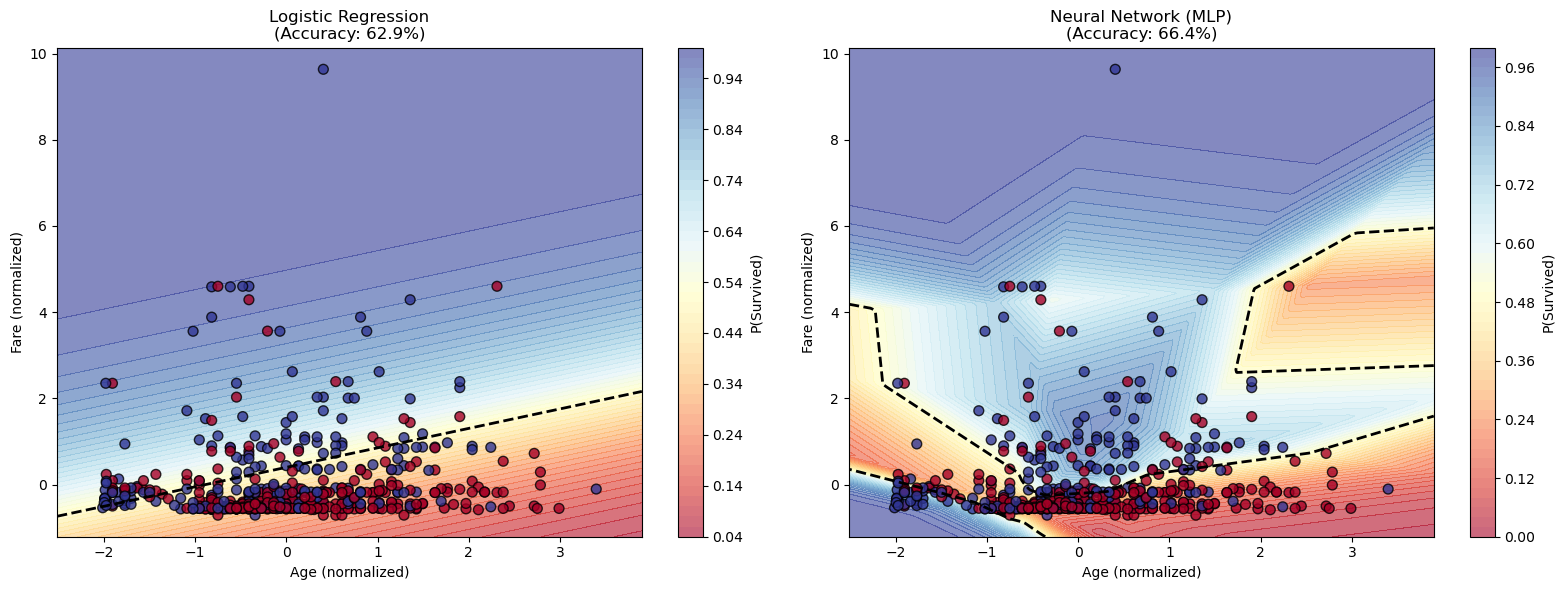

Left: Logistic regression with raw features — straight boundary.
Right: Neural network — learns its own features, can capture more complex patterns.


In [43]:
plot_comparison(
    X_train_2d_norm, y_train_2d, w_2d, b_2d, mlp_2d,
    'Logistic Regression', 'Neural Network (MLP)',
    val_acc_2d, mlp_2d_val_acc
)

print("Left: Logistic regression with raw features — straight boundary.")
print("Right: Neural network — learns its own features, can capture more complex patterns.")

## Why Does the MLP Learn Curved Boundaries?

This is the key question. Logistic regression draws a straight line. The MLP draws curves. What changed?

The answer: the hidden layer **creates new features** from the inputs. It takes the raw features (Age, Fare) and transforms them into 16 new numbers - each one a different weighted combination of the inputs, passed through ReLU. These 16 new features are not the same as the original inputs. They're *learned representations* - intermediate values that the network discovered are useful for this specific task.

Think of it this way: if you gave logistic regression the features [Age, Fare], it can only draw a straight line in that 2D space. But the hidden layer transforms [Age, Fare] into 16 new features. The output layer then does logistic regression in that 16-dimensional space - and a straight line in 16 dimensions, when projected back to the original 2D space, becomes a curve.

The network doesn't know it's learning curves. It's just doing weighted sums and ReLU, over and over. But the result is a model that can fit much more complex patterns. We'll explore exactly how this works - tracing actual numbers through each layer - in the next lesson.

### The Role of ReLU

Between layers, we apply **ReLU** (Rectified Linear Unit): it keeps positive values unchanged and sets negative values to zero. That's it. `ReLU(x) = max(0, x)`.

Why does something so simple matter so much? Because without it, stacking two linear layers is the same as having one linear layer. If layer 1 computes `y = Ax + b` and layer 2 computes `z = Cy + d`, then together they compute `z = C(Ax + b) + d = CAx + Cb + d` - which is just another linear function. You'd get the same result with a single layer. No matter how many linear layers you stack, the result is still linear. Still straight boundaries.

ReLU breaks the linearity. By zeroing out negative values, it introduces "bends" in the function. Those bends are what allow the network to learn curves instead of just straight lines. It's a simple operation, but it's the ingredient that makes deep learning work.

We'll explore ReLU more in the next lesson when we trace actual numbers through the network. For now, just know: ReLU is why the MLP can learn patterns that logistic regression can't.

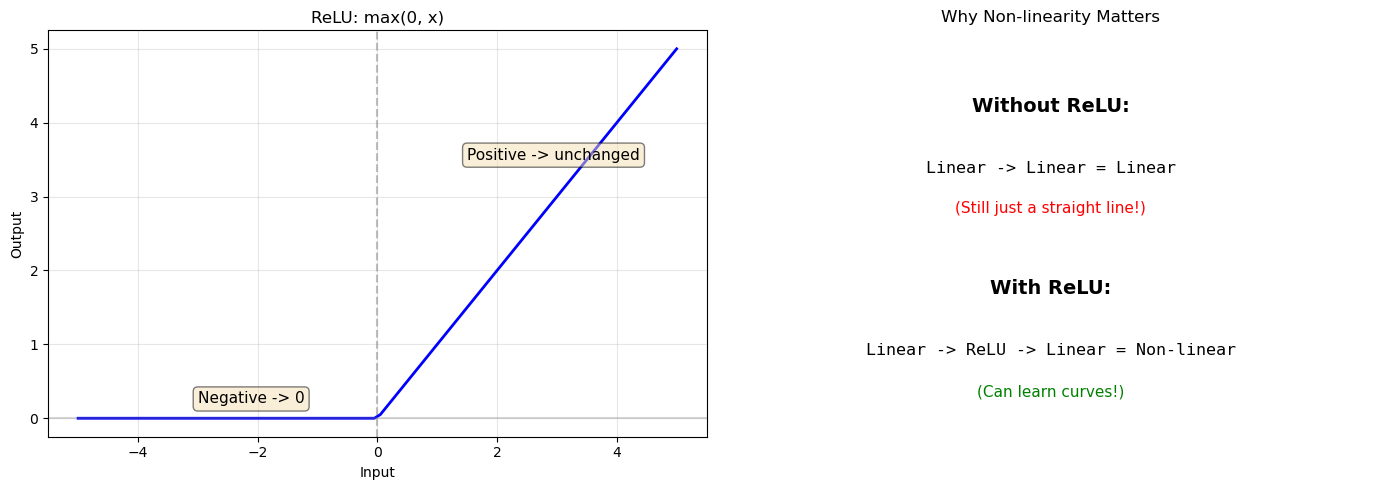

In [44]:
plot_relu()

### Quick Terminology Recap

We've introduced several new terms in this lesson. Here's a quick reference:

- **Layer** - a transformation step. Our MLP has three: input (4 features), hidden (16 neurons), output (1 probability)
- **Neuron** - one unit in a layer. Each neuron computes a weighted sum of its inputs and applies an activation function. Our hidden layer has 16 neurons, meaning it creates 16 different feature combinations.
- **Activation function** - the non-linear function applied after a layer's weighted sum. ReLU between hidden layers (introduces curves), Sigmoid at the output (produces probabilities).
- **Architecture** - the structure of a network: how many layers, how many neurons per layer, which activations. Ours is `Linear(4,16) -> ReLU -> Linear(16,1) -> Sigmoid`.

The next lesson goes much deeper into what each of these actually computes with real numbers.

## What's Happening Inside?

We've seen that the MLP works — it learns curved boundaries that logistic regression can't. But we've been treating it as a black box.

What actually happens when data flows through those layers? What do the hidden neurons compute? How does `loss.backward()` figure out which weights to blame?

**The next lesson opens the black box.** We'll:
- Trace real numbers through each layer, watching them transform
- Visualize what each neuron learns to detect
- Understand how gradients flow backward to update weights
- See the complete training loop in slow motion

You'll come away understanding not just *that* neural networks work, but *how* they work.

## Summary

**What we learned:**

1. **Classification** = predicting which group something belongs to (not a number)

2. **Logistic regression** = weighted sum → sigmoid → threshold. Simple, interpretable, but with basic features gives straight boundaries.

3. **Neural networks (MLPs)** = add hidden layers that automatically learn useful feature combinations. Can learn more complex patterns without manual feature engineering.

**The key insight:** Neural networks learn what features matter, instead of us having to figure it out manually.

**Next lesson:** We'll open the black box and see what's actually happening inside the neural network.

In [45]:
print("="*55)
print("RESULTS")
print("="*55)
print(f"{'Model':<25} {'Validation Accuracy':<20}")
print("-"*45)
print(f"{'Logistic Regression':<25} {val_accuracy:<20.1%}")
print(f"{'MLP (16 hidden neurons)':<25} {mlp_val_acc:<20.1%}")
print()
print("Both work! The MLP is slightly better here.")
print("The real advantage of neural networks shows on")
print("more complex data (images, text) where manual")
print("feature engineering would be impractical.")

RESULTS
Model                     Validation Accuracy 
---------------------------------------------
Logistic Regression       74.8%               
MLP (16 hidden neurons)   75.5%               

Both work! The MLP is slightly better here.
The real advantage of neural networks shows on
more complex data (images, text) where manual
feature engineering would be impractical.


<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>